# CascadeBoost

## Sección 1 · StratifiedTimeSeriesSplit

In [1]:
# ── Dependencias ───────────────────────────────────────────────────────────────
import warnings, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from scipy.stats import loguniform, randint, uniform

from sklearn.base            import BaseEstimator, ClassifierMixin, clone
from sklearn.tree            import DecisionTreeClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline as SkPipeline
from sklearn.model_selection import RandomizedSearchCV, BaseCrossValidator
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, auc, f1_score, roc_auc_score
)

from imblearn.ensemble  import RUSBoostClassifier
from imblearn.pipeline  import Pipeline as ImPipeline
from imblearn.over_sampling import SMOTE
from xgboost            import XGBClassifier

!pip install optuna deap -q
import optuna
from deap import base, creator, tools, algorithms

optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")
sns.set_theme(style='ticks', context='paper', font_scale=1.2, palette='Set1')

# ── Constantes globales ────────────────────────────────────────────────────────
RANDOM_STATE  = 42
N_SPLITS      = 3
N_ITER_S1     = 30     # Iteraciones Random Search para RUSBoost (Etapa 1)
N_ITER_S2     = 20     # Iteraciones Random Search para XGBoost  (Etapa 2)
BASE_PATH     = '/content/drive/MyDrive/Datasets/Final Project/Processed_v2/'

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

!pip install optuna deap -q

N_TRIALS_OPTUNA_S1 = 30   # igual que N_ITER_S1 del random search
N_TRIALS_OPTUNA_S2 = 20   # igual que N_ITER_S2 del random search
POP_SIZE_DEAP      = 10   # individuos por generación
N_GEN_DEAP         = 15   # generaciones (≈ 150 evaluaciones, comparable a random search)


class StratifiedTimeSeriesSplit(BaseCrossValidator):
    """
    Cross-validator temporal con bloques isoprevalentes.

    Divide el eje temporal en (n_splits + 1) bloques de forma que cada bloque
    contenga aproximadamente la misma cantidad de muestras de la clase positiva.
    El entrenamiento usa expanding window estricta.
    """

    def __init__(self, n_splits: int = 3, pos_label: int = 1):
        self.n_splits  = n_splits
        self.pos_label = pos_label

    def _iter_test_indices(self, X=None, y=None, groups=None):
        for _, test in self.split(X, y):
            yield test

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def _compute_cutpoints(self, y: np.ndarray) -> list[int]:
        n_total  = len(y)
        pos_idx  = np.where(y == self.pos_label)[0]
        n_pos    = len(pos_idx)
        n_blocks = self.n_splits + 1

        if n_pos < n_blocks:
            raise ValueError(
                f"Solo hay {n_pos} muestras positivas para {n_blocks} bloques. "
                f"Reduce n_splits o amplía el dataset."
            )

        block_size = n_pos // n_blocks
        cutpoints  = []
        for k in range(1, n_blocks):
            last_pos_in_block = pos_idx[k * block_size - 1]
            cutpoints.append(int(last_pos_in_block) + 1)
        cutpoints.append(n_total)
        return cutpoints

    def split(self, X, y, groups=None):
        y = np.asarray(y)
        cutpoints = self._compute_cutpoints(y)
        starts = [0] + cutpoints[:-1]
        ends   = cutpoints

        for k in range(self.n_splits):
            train_end = ends[k]
            val_start = starts[k + 1]
            val_end   = ends[k + 1]
            yield np.arange(0, train_end), np.arange(val_start, val_end)

    def get_split_stats(self, X, y) -> pd.DataFrame:
        y = np.asarray(y)
        rows = []
        for fold_i, (tr, va) in enumerate(self.split(X, y)):
            n_pos_val = int(np.sum(y[va] == self.pos_label))
            rows.append({
                'Fold'            : fold_i,
                'Train size'      : len(tr),
                'Val size'        : len(va),
                'Positivos en Val': n_pos_val,
                'Prevalencia Val' : f"{n_pos_val / len(va):.4%}",
            })
        return pd.DataFrame(rows)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 36.3 MB/s eta 0:00:00


## Sección 2 · Clases Auxiliares

In [2]:
class DynamicBalanceXGB(BaseEstimator, ClassifierMixin):
    """
    Wrapper de XGBoost que calcula scale_pos_weight DENTRO de cada fold
    para evitar data leakage. Usado en Etapa 2.
    """

    def __init__(
        self,
        use_balanced_weight: bool = False,
        learning_rate: float      = 0.1,
        max_depth: int            = 6,
        n_estimators: int         = 100,
        subsample: float          = 1.0,
        colsample_bytree: float   = 1.0,
        random_state: int         = RANDOM_STATE,
    ):
        self.use_balanced_weight = use_balanced_weight
        self.learning_rate       = learning_rate
        self.max_depth           = max_depth
        self.n_estimators        = n_estimators
        self.subsample           = subsample
        self.colsample_bytree    = colsample_bytree
        self.random_state        = random_state
        self.model_              = None

    def fit(self, X, y, **kwargs):
        spw = 1.0
        if self.use_balanced_weight and np.sum(y == 1) > 0:
            spw = np.sum(y == 0) / np.sum(y == 1)

        self.model_ = XGBClassifier(
            learning_rate    = self.learning_rate,
            max_depth        = self.max_depth,
            n_estimators     = self.n_estimators,
            subsample        = self.subsample,
            colsample_bytree = self.colsample_bytree,
            scale_pos_weight = spw,
            tree_method      = 'hist',
            device           = 'cuda',
            random_state     = self.random_state,
            n_jobs           = 1,
        )
        self.model_.fit(X, y, **kwargs)
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)

    @property
    def feature_importances_(self):
        return self.model_.feature_importances_

## Sección 3 · CascadeAMLClassifier

In [3]:
class CascadeAMLClassifier(BaseEstimator, ClassifierMixin):

    def __init__(
        self,
        stage1_params: dict = None,
        stage2_params: dict = None,
        theta1: float       = 0.3,
        theta2: float       = 0.5,
        mode: str           = 'soft',
    ):
        self.stage1_params = stage1_params or {}
        self.stage2_params = stage2_params or {}
        self.theta1        = theta1
        self.theta2        = theta2
        self.mode          = mode

    def _build_stage1(self):
        p = self.stage1_params
        return RUSBoostClassifier(
            estimator         = DecisionTreeClassifier(
                                    max_depth    = p.get('max_depth', 3),
                                    random_state = RANDOM_STATE,
                                ),
            n_estimators      = p.get('n_estimators', 200),
            learning_rate     = p.get('learning_rate', 0.5),
            sampling_strategy = p.get('sampling_strategy', 0.5),
            algorithm         = 'SAMME',
            random_state      = RANDOM_STATE,
        )

    def _build_stage2(self):
        p = self.stage2_params
        return DynamicBalanceXGB(
            use_balanced_weight = p.get('use_balanced_weight', True),
            learning_rate       = p.get('learning_rate', 0.1),
            max_depth           = p.get('max_depth', 6),
            n_estimators        = p.get('n_estimators', 100),
            subsample           = p.get('subsample', 0.8),
            colsample_bytree    = p.get('colsample_bytree', 0.8),
        )

    # ── Entrenamiento ──────────────────────────────────────────────────────────

    def fit(self, X, y, rus_oof_proba: np.ndarray = None):

        X_arr = np.array(X) if not isinstance(X, np.ndarray) else X
        y_arr = np.array(y)

        # ── Etapa 1: StandardScaler + RUSBoost ────────────────────────────────
        self.scaler_s1_ = StandardScaler()
        X_s1 = self.scaler_s1_.fit_transform(X_arr)
        self.stage1_ = self._build_stage1()
        self.stage1_.fit(X_s1, y_arr)

        # ── Señal de Etapa 1 para el entrenamiento de Etapa 2 ─────────────────
        if rus_oof_proba is not None:
            # Usar predicciones OOF (sin leakage temporal)
            stage1_signal = rus_oof_proba
        else:
            # Fallback: predicciones del modelo ya entrenado en train
            # (introduce leakage; usar solo para diagnóstico)
            stage1_signal = self.stage1_.predict_proba(X_s1)[:, 1]
            print("  ⚠ Advertencia: rus_oof_proba no proporcionado. "
                  "Usando predicciones in-sample (leakage potencial).")

        # ── Etapa 2: StandardScaler + XGBoost ─────────────────────────────────
        self.scaler_s2_ = StandardScaler()
        self.feature_names_s2_ = (
            list(X.columns) if hasattr(X, 'columns') else
            [f'f{i}' for i in range(X_arr.shape[1])]
        )

        if self.mode == 'hard':
            # Solo entrenamos XGBoost con las muestras que superan theta1
            mask_s2 = stage1_signal >= self.theta1
            if mask_s2.sum() < 10:
                raise ValueError(
                    f"Con theta1={self.theta1}, solo {mask_s2.sum()} muestras "
                    f"pasan a Etapa 2. Baja theta1 o revisa el modelo de Etapa 1."
                )
            X_s2 = self.scaler_s2_.fit_transform(X_arr[mask_s2])
            y_s2 = y_arr[mask_s2]
        else:
            # Modo soft: añadir rus_proba como feature adicional
            X_aug = np.column_stack([X_arr, stage1_signal])
            X_s2  = self.scaler_s2_.fit_transform(X_aug)
            y_s2  = y_arr

        self.stage2_ = self._build_stage2()
        self.stage2_.fit(X_s2, y_s2)

        # Guardar prevalencia de positivos en el subconjunto de E2 (diagnóstico)
        self.s2_pos_rate_ = float(y_s2.mean())
        self.s2_n_samples_ = int(len(y_s2))

        return self

    # ── Predicción ─────────────────────────────────────────────────────────────

    def _get_stage2_proba(self, X_arr: np.ndarray, stage1_proba: np.ndarray) -> np.ndarray:
        """Prepara input para Etapa 2 según el modo y devuelve probabilidades."""
        if self.mode == 'hard':
            # Solo predecimos sobre el subconjunto sospechoso
            mask_sus = stage1_proba >= self.theta1
            proba_s2 = np.zeros(len(X_arr))   # los negativos de E1 quedan en 0
            if mask_sus.sum() > 0:
                X_sus = self.scaler_s2_.transform(X_arr[mask_sus])
                proba_s2[mask_sus] = self.stage2_.predict_proba(X_sus)[:, 1]
            return proba_s2
        else:
            # Soft: todos pasan con la señal como feature extra
            X_aug = np.column_stack([X_arr, stage1_proba])
            X_s2  = self.scaler_s2_.transform(X_aug)
            return self.stage2_.predict_proba(X_s2)[:, 1]

    def predict_proba(self, X):
        X_arr = np.array(X) if not isinstance(X, np.ndarray) else X
        X_s1  = self.scaler_s1_.transform(X_arr)

        # Etapa 1
        stage1_proba = self.stage1_.predict_proba(X_s1)[:, 1]

        # Etapa 2
        stage2_proba = self._get_stage2_proba(X_arr, stage1_proba)

        proba_pos = stage2_proba
        return np.column_stack([1 - proba_pos, proba_pos])

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= self.theta2).astype(int)

    def predict_stages(self, X):

        X_arr = np.array(X) if not isinstance(X, np.ndarray) else X
        X_s1  = self.scaler_s1_.transform(X_arr)

        stage1_proba = self.stage1_.predict_proba(X_s1)[:, 1]
        stage2_proba = self._get_stage2_proba(X_arr, stage1_proba)
        final_pred   = (stage2_proba >= self.theta2).astype(int)

        return stage1_proba, stage2_proba, final_pred

## Sección 4 · Carga de Datos

In [4]:
from google.colab import drive
drive.mount('/content/drive')

X_train = pd.read_parquet(f'{BASE_PATH}X_train_v3.parquet')
X_test  = pd.read_parquet(f'{BASE_PATH}X_test_v3.parquet')
y_train = pd.read_parquet(f'{BASE_PATH}y_train_v3.parquet')['Is Laundering']
y_test  = pd.read_parquet(f'{BASE_PATH}y_test_v3.parquet')['Is Laundering']

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"Prevalencia — Train: {y_train.mean():.4%}  |  Test: {y_test.mean():.4%}")

Mounted at /content/drive
X_train : (4062668, 64)  |  y_train : (4062668,)
X_test  : (1015668, 64)   |  y_test  : (1015668,)
Prevalencia — Train: 0.0832%  |  Test: 0.1770%


### Visualización de StratifiedTimeSeriesSplit
Comportamiento del particionamiento temporal a lo largo de los folds.

Estadísticas de los Folds:


,Fold,Train size,Val size,Positivos en Val,Prevalencia Val
0,0,1945726,534567,844,0.1579%
1,1,2480293,770312,844,0.1096%
2,2,3250605,812063,847,0.1043%


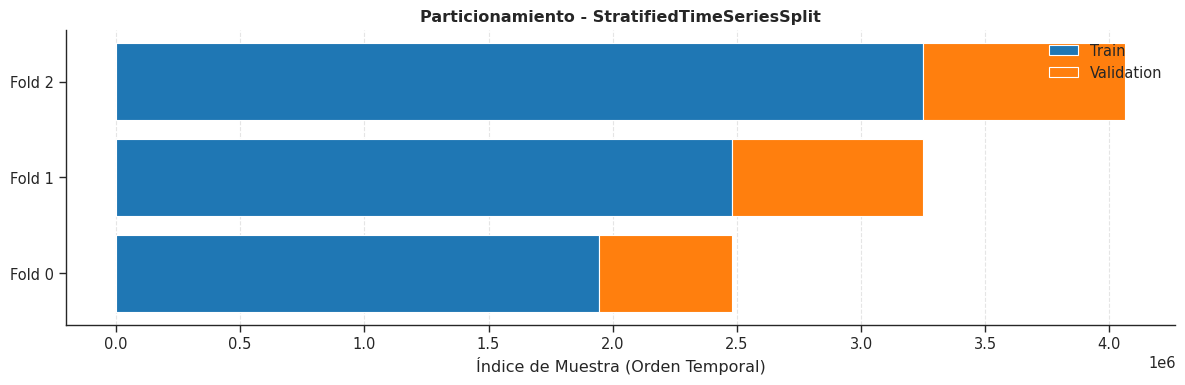

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display

def plot_cv_splits_fast(cv, X, y):
    """
    Visualiza los particionamientos (Train / Validation) usando barras
    horizontales (broken_barh), lo cual es rápido para millones de registros.
    """
    n_splits = cv.get_n_splits()
    fig, ax = plt.subplots(figsize=(12, 4))

    # Paleta de colores
    color_train = '#1f77b4' # Azul
    color_val = '#ff7f0e'   # Naranja

    for i, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        # Graficar bloque de entrenamiento
        ax.broken_barh([(train_idx[0], train_idx[-1] - train_idx[0])],
                       (i + 0.6, 0.8),
                       facecolors=color_train,
                       label='Train' if i == 0 else '')

        # Graficar bloque de validación
        ax.broken_barh([(val_idx[0], val_idx[-1] - val_idx[0])],
                       (i + 0.6, 0.8),
                       facecolors=color_val,
                       label='Validation' if i == 0 else '')

    ax.set_yticks(np.arange(1, n_splits + 1))
    ax.set_yticklabels([f'Fold {i}' for i in range(n_splits)])
    ax.set_xlabel('Índice de Muestra (Orden Temporal)')
    ax.set_title('Particionamiento - StratifiedTimeSeriesSplit', fontweight='bold')
    ax.legend(loc='upper right', frameon=False)

    ax.grid(axis='x', linestyle='--', alpha=0.5)
    sns.despine()
    plt.tight_layout()
    plt.show()

# 1. Instanciar el CV con la configuración global
cv_vis = StratifiedTimeSeriesSplit(n_splits=N_SPLITS)

# 2. Imprimir las estadísticas tabulares
print("Estadísticas de los Folds:")
stats_df = cv_vis.get_split_stats(X_train, y_train)
display(stats_df)

# 3. Graficar la división
plot_cv_splits_fast(cv_vis, X_train, y_train)

## Sección 5 · Búsqueda de Hiperparámetros

### RandomSearch


══════════════════════════════════════════════════════════════
 Búsqueda Etapa 1 — RUSBoost (filtro de alto recall)
══════════════════════════════════════════════════════════════
 Scoring    : F1   (recall alto con theta1 bajo en inferencia)
 Iteraciones: 30  ×  3 folds = 90 fits

Fitting 3 folds for each of 30 candidates, totalling 90 fits

══════════════════════════════════════════════════════════════
  ✓ Mejor F1 (CV) Etapa 1 : 0.0866
  ✓ n_estimators          : 264
  ✓ learning_rate         : 0.32048
  ✓ sampling_strategy     : 0.1523
  ✓ max_depth (árbol)     : 5
  ✓ Tiempo                : 3.3 min
══════════════════════════════════════════════════════════════

  Fold 0: train=1,945,726  val=534,567  pos_val=  844  ✓
  Fold 1: train=2,480,293  val=770,312  pos_val=  844  ✓
  Fold 2: train=3,250,605  val=812,063  pos_val=  847  ✓

  Cobertura OOF: 2,116,942 / 4,062,668 muestras (52.1%)
  El bloque 0 (≈1,945,726 muestras) nunca es validación → oof_proba=0.0 (se excluye del entrenam

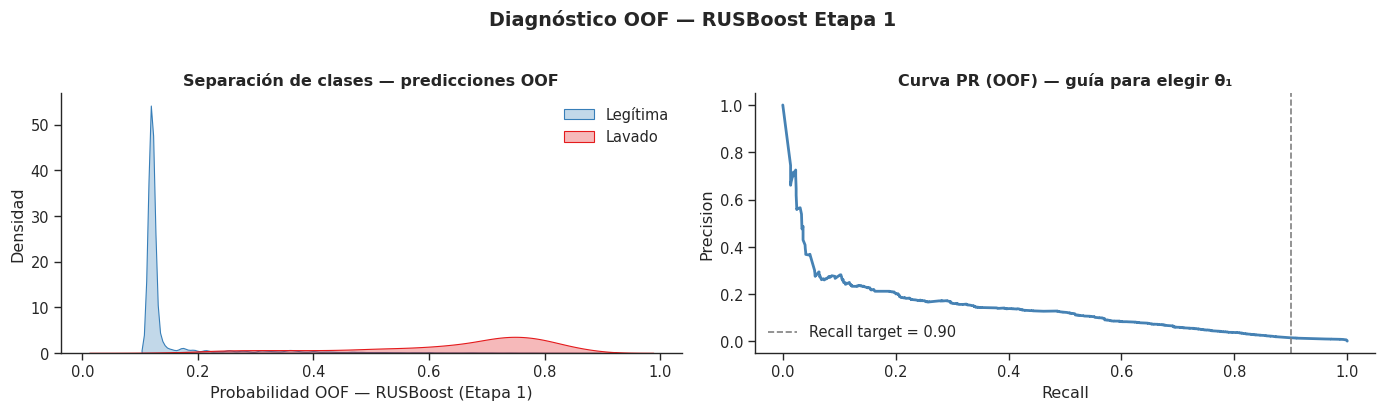


  θ₁ sugerido para recall ≥ 99% en OOF : 0.1915
  (puedes ajustarlo manualmente más adelante)


══════════════════════════════════════════════════════════════
 Búsqueda Etapa 2 — XGBoost (modo HARD, θ₁=0.1915)
══════════════════════════════════════════════════════════════
 Muestras para E2 : 302,904  (7.5% del total)
 Positivos        : 2,511  (0.8290% prevalencia)
 Iteraciones      : 20  ×  3 folds = 60 fits

Fitting 3 folds for each of 20 candidates, totalling 60 fits

══════════════════════════════════════════════════════════════
  ✓ Mejor F1 (CV) Etapa 2 : 0.4344
  ✓ learning_rate         : 0.06155
  ✓ max_depth             : 10
  ✓ n_estimators          : 203
  ✓ subsample             : 0.9826
  ✓ colsample_bytree      : 0.8737
  ✓ Tiempo                : 0.6 min
══════════════════════════════════════════════════════════════



In [ ]:
PARAM_DIST_S1 = {
    'clf__n_estimators'        : randint(50, 501),
    'clf__learning_rate'       : uniform(0.01, 1.99),
    'clf__sampling_strategy'   : uniform(0.1, 0.9),
    'clf__estimator__max_depth': randint(1, 6),
}


def search_stage1(X_train, y_train, n_iter=N_ITER_S1) -> dict:
    """Random Search para RUSBoost (Etapa 1) con StratifiedTimeSeriesSplit."""

    print(f"\n{'═'*62}")
    print(f" Búsqueda Etapa 1 — RUSBoost (filtro de alto recall)")
    print(f"{'═'*62}")
    print(f" Scoring    : F1   (recall alto con theta1 bajo en inferencia)")
    print(f" Iteraciones: {n_iter}  ×  {N_SPLITS} folds = {n_iter * N_SPLITS} fits\n")

    cv = StratifiedTimeSeriesSplit(n_splits=N_SPLITS)

    pipe = SkPipeline([
        ('scaler', StandardScaler()),
        ('clf',    RUSBoostClassifier(
            estimator    = DecisionTreeClassifier(random_state=RANDOM_STATE),
            random_state = RANDOM_STATE,
            algorithm    = 'SAMME',
        )),
    ])

    search = RandomizedSearchCV(
        pipe, PARAM_DIST_S1,
        n_iter       = n_iter,
        cv           = cv,
        scoring      = 'f1',          # cambiar a 'recall' para priorizar recall máximo
        n_jobs       = -1,
        refit        = False,
        random_state = RANDOM_STATE,
        verbose      = 1,
    )

    t0 = time.time()
    search.fit(X_train, y_train)
    elapsed = (time.time() - t0) / 60

    best_f1 = search.best_score_
    p       = search.best_params_

    spec_s1 = {
        'n_estimators'      : p['clf__n_estimators'],
        'learning_rate'     : p['clf__learning_rate'],
        'sampling_strategy' : p['clf__sampling_strategy'],
        'max_depth'         : p['clf__estimator__max_depth'],
    }

    print(f"\n{'═'*62}")
    print(f"  ✓ Mejor F1 (CV) Etapa 1 : {best_f1:.4f}")
    print(f"  ✓ n_estimators          : {spec_s1['n_estimators']}")
    print(f"  ✓ learning_rate         : {spec_s1['learning_rate']:.5f}")
    print(f"  ✓ sampling_strategy     : {spec_s1['sampling_strategy']:.4f}")
    print(f"  ✓ max_depth (árbol)     : {spec_s1['max_depth']}")
    print(f"  ✓ Tiempo                : {elapsed:.1f} min")
    print(f"{'═'*62}\n")

    return {
        'spec'      : spec_s1,
        'best_f1'   : best_f1,
        'detail_df' : pd.DataFrame(search.cv_results_),
    }


result_s1 = search_stage1(X_train, y_train)
spec_s1   = result_s1['spec']

def generate_oof_stage1(X_train, y_train, spec_s1, n_splits=N_SPLITS) -> np.ndarray:

    X_arr  = X_train.values
    y_arr  = y_train.values
    cv     = StratifiedTimeSeriesSplit(n_splits=n_splits)
    scaler = StandardScaler()

    oof_proba  = np.zeros(len(y_arr))
    oof_mask   = np.zeros(len(y_arr), dtype=bool)  # qué índices tienen OOF real

    for fold_i, (tr_idx, va_idx) in enumerate(cv.split(X_arr, y_arr)):
        # Escalar solo con datos de train (sin filtración futura)
        sc = StandardScaler()
        Xtr_s = sc.fit_transform(X_arr[tr_idx])
        Xva_s = sc.transform(X_arr[va_idx])

        rus = RUSBoostClassifier(
            estimator         = DecisionTreeClassifier(
                                    max_depth    = spec_s1['max_depth'],
                                    random_state = RANDOM_STATE,
                                ),
            n_estimators      = spec_s1['n_estimators'],
            learning_rate     = spec_s1['learning_rate'],
            sampling_strategy = spec_s1['sampling_strategy'],
            algorithm         = 'SAMME',
            random_state      = RANDOM_STATE,
        )
        rus.fit(Xtr_s, y_arr[tr_idx])
        oof_proba[va_idx] = rus.predict_proba(Xva_s)[:, 1]
        oof_mask[va_idx]  = True

        n_pos_va = y_arr[va_idx].sum()
        print(f"  Fold {fold_i}: train={len(tr_idx):>6,}  val={len(va_idx):>6,}  "
              f"pos_val={n_pos_va:>5,}  ✓")

    print(f"\n  Cobertura OOF: {oof_mask.sum():,} / {len(y_arr):,} muestras "
          f"({oof_mask.mean():.1%})")
    print(f"  El bloque 0 (≈{(~oof_mask).sum():,} muestras) nunca es validación "
          f"→ oof_proba=0.0 (se excluye del entrenamiento de E2 en modo hard)")

    return oof_proba, oof_mask


rus_oof_proba, oof_mask = generate_oof_stage1(X_train, y_train, spec_s1)

# Diagnóstico: distribución de probabilidades OOF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = sns.color_palette('Set1')
for cls, lbl, c in [(0, 'Legítima', colors[1]), (1, 'Lavado', colors[0])]:
    mask_cls = (y_train.values[oof_mask] == cls)
    sns.kdeplot(
        rus_oof_proba[oof_mask][mask_cls],
        ax=axes[0], color=c, fill=True, alpha=0.3, label=lbl
    )
axes[0].set_xlabel('Probabilidad OOF — RUSBoost (Etapa 1)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Separación de clases — predicciones OOF', fontweight='bold')
axes[0].legend(frameon=False)
sns.despine(ax=axes[0])

# Curva PR sobre OOF para elegir theta1
prec_oof, rec_oof, th_oof = precision_recall_curve(
    y_train.values[oof_mask], rus_oof_proba[oof_mask]
)
axes[1].plot(rec_oof, prec_oof, lw=2, color='steelblue')
axes[1].axvline(0.90, color='gray', linestyle='--', lw=1.2, label='Recall target = 0.90')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva PR (OOF) — guía para elegir θ₁', fontweight='bold')
axes[1].legend(frameon=False)
sns.despine(ax=axes[1])

plt.suptitle('Diagnóstico OOF — RUSBoost Etapa 1', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}cascade_oof_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Sugerir theta1 automáticamente: umbral que logra recall ≥ 90% en OOF ─────
target_recall = 0.99
valid_th = th_oof[rec_oof[:-1] >= target_recall]
THETA1_AUTO = float(valid_th[-1]) if len(valid_th) > 0 else 0.3

print(f"\n  θ₁ sugerido para recall ≥ {target_recall:.0%} en OOF : {THETA1_AUTO:.4f}")
print(f"  (puedes ajustarlo manualmente más adelante)\n")

THETA1 = THETA1_AUTO   # usar el sugerido automáticamente o ajustar manualmente
THETA2 = 0.5           # se optimizará post-entrenamiento si se desea

PARAM_DIST_S2 = {
    'clf__learning_rate'    : loguniform(0.01, 0.29),
    'clf__max_depth'        : randint(3, 11),
    'clf__n_estimators'     : randint(50, 301),
    'clf__subsample'        : uniform(0.5, 0.5),
    'clf__colsample_bytree' : uniform(0.5, 0.5),
}


def search_stage2_hard(
    X_train, y_train,
    rus_oof_proba, oof_mask,
    theta1=THETA1,
    n_iter=N_ITER_S2,
) -> dict:

    print(f"\n{'═'*62}")
    print(f" Búsqueda Etapa 2 — XGBoost (modo HARD, θ₁={theta1:.4f})")
    print(f"{'═'*62}")

    X_arr = X_train.values
    y_arr = y_train.values

    # ── Filtrar: solo muestras OOF con rus_proba ≥ theta1 ────────────────────
    mask_s2 = oof_mask & (rus_oof_proba >= theta1)

    n_total  = mask_s2.sum()
    n_pos    = int(y_arr[mask_s2].sum())
    prev_s2  = y_arr[mask_s2].mean()

    print(f" Muestras para E2 : {n_total:,}  ({n_total/len(y_arr):.1%} del total)")
    print(f" Positivos        : {n_pos:,}  ({prev_s2:.4%} prevalencia)")
    print(f" Iteraciones      : {n_iter}  ×  {N_SPLITS} folds = {n_iter * N_SPLITS} fits\n")

    X_s2 = X_arr[mask_s2]
    y_s2 = y_arr[mask_s2]

    cv = StratifiedTimeSeriesSplit(n_splits=N_SPLITS)

    pipe = ImPipeline([
        ('scaler', StandardScaler()),
        ('clf',    DynamicBalanceXGB(use_balanced_weight=True)),
    ])

    search = RandomizedSearchCV(
        pipe, PARAM_DIST_S2,
        n_iter       = n_iter,
        cv           = cv,
        scoring      = 'f1',
        n_jobs       = -1,
        refit        = False,
        random_state = RANDOM_STATE,
        verbose      = 1,
    )

    t0 = time.time()
    search.fit(X_s2, y_s2)
    elapsed = (time.time() - t0) / 60

    best_f1 = search.best_score_
    p       = search.best_params_

    spec_s2 = {
        'learning_rate'     : p['clf__learning_rate'],
        'max_depth'         : p['clf__max_depth'],
        'n_estimators'      : p['clf__n_estimators'],
        'subsample'         : p['clf__subsample'],
        'colsample_bytree'  : p['clf__colsample_bytree'],
        'use_balanced_weight': True,
    }

    print(f"\n{'═'*62}")
    print(f"  ✓ Mejor F1 (CV) Etapa 2 : {best_f1:.4f}")
    print(f"  ✓ learning_rate         : {spec_s2['learning_rate']:.5f}")
    print(f"  ✓ max_depth             : {spec_s2['max_depth']}")
    print(f"  ✓ n_estimators          : {spec_s2['n_estimators']}")
    print(f"  ✓ subsample             : {spec_s2['subsample']:.4f}")
    print(f"  ✓ colsample_bytree      : {spec_s2['colsample_bytree']:.4f}")
    print(f"  ✓ Tiempo                : {elapsed:.1f} min")
    print(f"{'═'*62}\n")

    return {
        'spec'      : spec_s2,
        'best_f1'   : best_f1,
        'detail_df' : pd.DataFrame(search.cv_results_),
        'mask_s2'   : mask_s2,
        'prev_s2'   : prev_s2,
    }


result_s2 = search_stage2_hard(X_train, y_train, rus_oof_proba, oof_mask, theta1=THETA1)
spec_s2   = result_s2['spec']

### Gridsearch

In [ ]:
PARAM_GRID_S1 = {
    'clf__n_estimators'        : [100, 300, 500],
    'clf__learning_rate'       : [0.05, 0.5, 1.0],
    'clf__sampling_strategy'   : [0.2, 0.5, 0.8],
    'clf__estimator__max_depth': [1, 3, 5],
}

def search_stage1_grid(X_train, y_train) -> dict:
    """Grid Search exhaustivo para RUSBoost (Etapa 1) con StratifiedTimeSeriesSplit."""

    n_combos = 1
    for v in PARAM_GRID_S1.values():
        n_combos *= len(v)

    print(f"\n{'═'*62}")
    print(f" GridSearch Etapa 1 — RUSBoost (filtro de alto recall)")
    print(f"{'═'*62}")
    print(f" Scoring       : F1")
    print(f" Combinaciones : {n_combos}  ×  {N_SPLITS} folds = {n_combos * N_SPLITS} fits\n")

    cv = StratifiedTimeSeriesSplit(n_splits=N_SPLITS)

    pipe = SkPipeline([
        ('scaler', StandardScaler()),
        ('clf',    RUSBoostClassifier(
            estimator    = DecisionTreeClassifier(random_state=RANDOM_STATE),
            random_state = RANDOM_STATE,
            algorithm    = 'SAMME',
        )),
    ])

    search = GridSearchCV(
        pipe, PARAM_GRID_S1,
        cv      = cv,
        scoring = 'f1',
        n_jobs  = -1,
        refit   = False,
        verbose = 1,
    )

    t0 = time.time()
    search.fit(X_train, y_train)
    elapsed = (time.time() - t0) / 60

    best_f1 = search.best_score_
    p       = search.best_params_

    spec_s1_grid = {
        'n_estimators'      : p['clf__n_estimators'],
        'learning_rate'     : p['clf__learning_rate'],
        'sampling_strategy' : p['clf__sampling_strategy'],
        'max_depth'         : p['clf__estimator__max_depth'],
    }

    print(f"\n{'═'*62}")
    print(f"  ✓ Mejor F1 (CV) Etapa 1 : {best_f1:.4f}")
    print(f"  ✓ n_estimators          : {spec_s1_grid['n_estimators']}")
    print(f"  ✓ learning_rate         : {spec_s1_grid['learning_rate']:.5f}")
    print(f"  ✓ sampling_strategy     : {spec_s1_grid['sampling_strategy']:.4f}")
    print(f"  ✓ max_depth (árbol)     : {spec_s1_grid['max_depth']}")
    print(f"  ✓ Tiempo                : {elapsed:.1f} min")
    print(f"{'═'*62}\n")

    return {
        'spec'      : spec_s1_grid,
        'best_f1'   : best_f1,
        'detail_df' : pd.DataFrame(search.cv_results_),
    }


result_s1_grid = search_stage1_grid(X_train, y_train)
spec_s1_grid   = result_s1_grid['spec']


"""## Sección A2 · GridSearch — OOF Etapa 1 (sin leakage)"""

rus_oof_proba_grid, oof_mask_grid = generate_oof_stage1(X_train, y_train, spec_s1_grid)

# Sugerir theta1 automáticamente: umbral que logra recall ≥ 99% en OOF
prec_oof_g, rec_oof_g, th_oof_g = precision_recall_curve(
    y_train.values[oof_mask_grid], rus_oof_proba_grid[oof_mask_grid]
)
valid_th_g      = th_oof_g[rec_oof_g[:-1] >= 0.99]
THETA1_GRID_AUTO = float(valid_th_g[-1]) if len(valid_th_g) > 0 else 0.3
print(f"\n  [GridSearch] θ₁ sugerido para recall ≥ 99% en OOF : {THETA1_GRID_AUTO:.4f}")


"""## Sección A3 · GridSearch — Etapa 2 (XGBoost)"""

PARAM_GRID_S2 = {
    'clf__learning_rate'    : [0.01, 0.05, 0.1],
    'clf__max_depth'        : [3, 6, 9],
    'clf__n_estimators'     : [100, 200, 300],
    'clf__subsample'        : [0.6, 0.8],
    'clf__colsample_bytree' : [0.6, 0.8],
}

def search_stage2_grid(
    X_train, y_train,
    rus_oof_proba, oof_mask,
    theta1=THETA1_GRID_AUTO,
) -> dict:
    """Grid Search exhaustivo para XGBoost (Etapa 2) con StratifiedTimeSeriesSplit."""

    n_combos = 1
    for v in PARAM_GRID_S2.values():
        n_combos *= len(v)

    print(f"\n{'═'*62}")
    print(f" GridSearch Etapa 2 — XGBoost (modo HARD, θ₁={theta1:.4f})")
    print(f"{'═'*62}")

    X_arr = X_train.values
    y_arr = y_train.values

    mask_s2 = oof_mask & (rus_oof_proba >= theta1)
    n_total  = mask_s2.sum()
    n_pos    = int(y_arr[mask_s2].sum())
    prev_s2  = y_arr[mask_s2].mean()

    print(f" Muestras para E2  : {n_total:,}  ({n_total/len(y_arr):.1%} del total)")
    print(f" Positivos         : {n_pos:,}  ({prev_s2:.4%} prevalencia)")
    print(f" Combinaciones     : {n_combos}  ×  {N_SPLITS} folds = {n_combos * N_SPLITS} fits\n")

    X_s2 = X_arr[mask_s2]
    y_s2 = y_arr[mask_s2]

    cv = StratifiedTimeSeriesSplit(n_splits=N_SPLITS)

    pipe = ImPipeline([
        ('scaler', StandardScaler()),
        ('clf',    DynamicBalanceXGB(use_balanced_weight=True)),
    ])

    search = GridSearchCV(
        pipe, PARAM_GRID_S2,
        cv      = cv,
        scoring = 'f1',
        n_jobs  = -1,
        refit   = False,
        verbose = 1,
    )

    t0 = time.time()
    search.fit(X_s2, y_s2)
    elapsed = (time.time() - t0) / 60

    best_f1 = search.best_score_
    p       = search.best_params_

    spec_s2_grid = {
        'learning_rate'      : p['clf__learning_rate'],
        'max_depth'          : p['clf__max_depth'],
        'n_estimators'       : p['clf__n_estimators'],
        'subsample'          : p['clf__subsample'],
        'colsample_bytree'   : p['clf__colsample_bytree'],
        'use_balanced_weight': True,
    }

    print(f"\n{'═'*62}")
    print(f"  ✓ Mejor F1 (CV) Etapa 2 : {best_f1:.4f}")
    print(f"  ✓ learning_rate         : {spec_s2_grid['learning_rate']:.5f}")
    print(f"  ✓ max_depth             : {spec_s2_grid['max_depth']}")
    print(f"  ✓ n_estimators          : {spec_s2_grid['n_estimators']}")
    print(f"  ✓ subsample             : {spec_s2_grid['subsample']:.4f}")
    print(f"  ✓ colsample_bytree      : {spec_s2_grid['colsample_bytree']:.4f}")
    print(f"  ✓ Tiempo                : {elapsed:.1f} min")
    print(f"{'═'*62}\n")

    return {
        'spec'      : spec_s2_grid,
        'best_f1'   : best_f1,
        'detail_df' : pd.DataFrame(search.cv_results_),
        'mask_s2'   : mask_s2,
        'prev_s2'   : prev_s2,
    }


result_s2_grid = search_stage2_grid(
    X_train, y_train,
    rus_oof_proba_grid, oof_mask_grid,
    theta1=THETA1_GRID_AUTO,
)
spec_s2_grid = result_s2_grid['spec']


══════════════════════════════════════════════════════════════
 GridSearch Etapa 1 — RUSBoost (filtro de alto recall)
══════════════════════════════════════════════════════════════
 Scoring       : F1
 Combinaciones : 81  ×  3 folds = 243 fits

Fitting 3 folds for each of 81 candidates, totalling 243 fits

══════════════════════════════════════════════════════════════
  ✓ Mejor F1 (CV) Etapa 1 : 0.0852
  ✓ n_estimators          : 100
  ✓ learning_rate         : 0.05000
  ✓ sampling_strategy     : 0.2000
  ✓ max_depth (árbol)     : 5
  ✓ Tiempo                : 13.9 min
══════════════════════════════════════════════════════════════

  Fold 0: train=1,945,726  val=534,567  pos_val=  844  ✓
  Fold 1: train=2,480,293  val=770,312  pos_val=  844  ✓
  Fold 2: train=3,250,605  val=812,063  pos_val=  847  ✓

  Cobertura OOF: 2,116,942 / 4,062,668 muestras (52.1%)
  El bloque 0 (≈1,945,726 muestras) nunca es validación → oof_proba=0.0 (se excluye del entrenamiento de E2 en modo hard)

  [GridS

### Optuna


══════════════════════════════════════════════════════════════
 Optuna (TPE) Etapa 1 — RUSBoost (filtro de alto recall)
══════════════════════════════════════════════════════════════
 Scoring : F1   |   Trials : 30  ×  3 folds = 90 fits



  0%|          | 0/30 [00:00<?, ?it/s]


══════════════════════════════════════════════════════════════
  ✓ Mejor F1 (CV) Etapa 1 : 0.1073
  ✓ n_estimators          : 51
  ✓ learning_rate         : 0.03274
  ✓ sampling_strategy     : 0.1009
  ✓ max_depth (árbol)     : 5
  ✓ Tiempo                : 40.1 min
══════════════════════════════════════════════════════════════



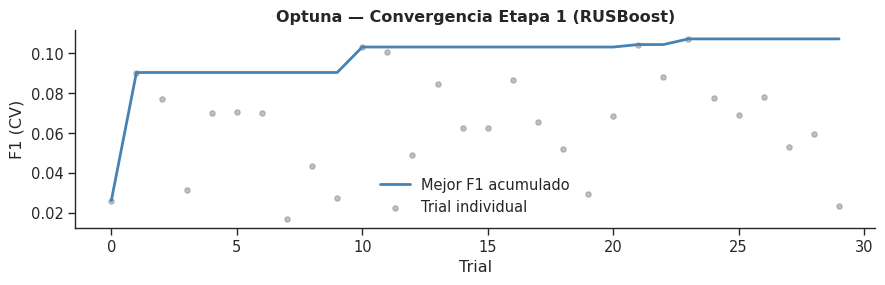

  Fold 0: train=1,945,726  val=534,567  pos_val=  844  ✓
  Fold 1: train=2,480,293  val=770,312  pos_val=  844  ✓
  Fold 2: train=3,250,605  val=812,063  pos_val=  847  ✓

  Cobertura OOF: 2,116,942 / 4,062,668 muestras (52.1%)
  El bloque 0 (≈1,945,726 muestras) nunca es validación → oof_proba=0.0 (se excluye del entrenamiento de E2 en modo hard)

  [Optuna] θ₁ sugerido para recall ≥ 99% en OOF : 0.1980

══════════════════════════════════════════════════════════════
 Optuna (TPE) Etapa 2 — XGBoost (modo HARD, θ₁=0.1980)
══════════════════════════════════════════════════════════════
 Muestras para E2 : 284,906  (7.0% del total)
 Positivos        : 2,510  (0.8810% prevalencia)
 Trials           : 20  ×  3 folds = 60 fits



  0%|          | 0/20 [00:00<?, ?it/s]


══════════════════════════════════════════════════════════════
  ✓ Mejor F1 (CV) Etapa 2 : 0.5026
  ✓ learning_rate         : 0.26696
  ✓ max_depth             : 8
  ✓ n_estimators          : 300
  ✓ subsample             : 0.9235
  ✓ colsample_bytree      : 0.8605
  ✓ Tiempo                : 1.0 min
══════════════════════════════════════════════════════════════



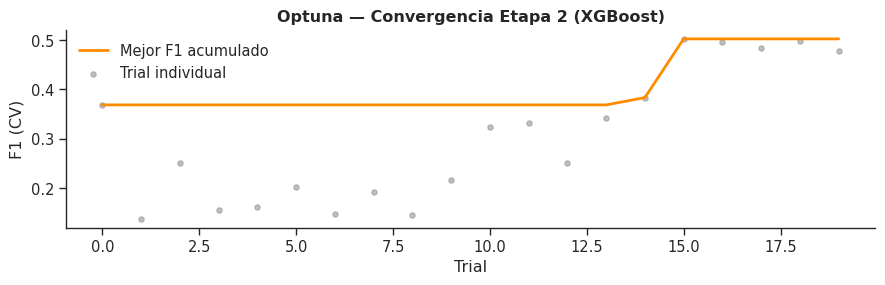

In [ ]:
def search_stage1_optuna(X_train, y_train, n_trials=N_TRIALS_OPTUNA_S1) -> dict:
    """
    Optimización Bayesiana (TPE) para RUSBoost (Etapa 1).
    Optuna muestrea el espacio de forma inteligente usando el historial de trials.
    """

    print(f"\n{'═'*62}")
    print(f" Optuna (TPE) Etapa 1 — RUSBoost (filtro de alto recall)")
    print(f"{'═'*62}")
    print(f" Scoring : F1   |   Trials : {n_trials}  ×  {N_SPLITS} folds = {n_trials * N_SPLITS} fits\n")

    cv = StratifiedTimeSeriesSplit(n_splits=N_SPLITS)

    def objective_s1(trial):
        params = {
            'n_estimators'      : trial.suggest_int  ('n_estimators',       50,   500),
            'learning_rate'     : trial.suggest_float('learning_rate',     0.01,  2.0,  log=True),
            'sampling_strategy' : trial.suggest_float('sampling_strategy', 0.1,   0.9),
            'max_depth'         : trial.suggest_int  ('max_depth',           1,     5),
        }

        pipe = SkPipeline([
            ('scaler', StandardScaler()),
            ('clf',    RUSBoostClassifier(
                estimator         = DecisionTreeClassifier(
                                        max_depth    = params['max_depth'],
                                        random_state = RANDOM_STATE,
                                    ),
                n_estimators      = params['n_estimators'],
                learning_rate     = params['learning_rate'],
                sampling_strategy = params['sampling_strategy'],
                algorithm         = 'SAMME',
                random_state      = RANDOM_STATE,
            )),
        ])

        scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
        return scores.mean()

    study_s1 = optuna.create_study(
        direction  = 'maximize',
        sampler    = optuna.samplers.TPESampler(seed=RANDOM_STATE),
        study_name = 'stage1_rusboost',
    )

    t0 = time.time()
    study_s1.optimize(objective_s1, n_trials=n_trials, show_progress_bar=True)
    elapsed = (time.time() - t0) / 60

    best = study_s1.best_params
    best_f1 = study_s1.best_value

    spec_s1_optuna = {
        'n_estimators'      : best['n_estimators'],
        'learning_rate'     : best['learning_rate'],
        'sampling_strategy' : best['sampling_strategy'],
        'max_depth'         : best['max_depth'],
    }

    print(f"\n{'═'*62}")
    print(f"  ✓ Mejor F1 (CV) Etapa 1 : {best_f1:.4f}")
    print(f"  ✓ n_estimators          : {spec_s1_optuna['n_estimators']}")
    print(f"  ✓ learning_rate         : {spec_s1_optuna['learning_rate']:.5f}")
    print(f"  ✓ sampling_strategy     : {spec_s1_optuna['sampling_strategy']:.4f}")
    print(f"  ✓ max_depth (árbol)     : {spec_s1_optuna['max_depth']}")
    print(f"  ✓ Tiempo                : {elapsed:.1f} min")
    print(f"{'═'*62}\n")

    # Visualización rápida de la convergencia
    fig_opt, ax_opt = plt.subplots(figsize=(9, 3))
    trials_df = study_s1.trials_dataframe()
    ax_opt.plot(trials_df.index, trials_df['value'].cummax(), lw=2, color='steelblue', label='Mejor F1 acumulado')
    ax_opt.scatter(trials_df.index, trials_df['value'], s=15, color='gray', alpha=0.5, label='Trial individual')
    ax_opt.set_xlabel('Trial')
    ax_opt.set_ylabel('F1 (CV)')
    ax_opt.set_title('Optuna — Convergencia Etapa 1 (RUSBoost)', fontweight='bold')
    ax_opt.legend(frameon=False)
    sns.despine(ax=ax_opt)
    plt.tight_layout()
    plt.show()

    return {
        'spec'      : spec_s1_optuna,
        'best_f1'   : best_f1,
        'study'     : study_s1,
        'detail_df' : study_s1.trials_dataframe(),
    }


result_s1_optuna = search_stage1_optuna(X_train, y_train)
spec_s1_optuna   = result_s1_optuna['spec']


"""## Sección B2 · Optuna — OOF Etapa 1 (sin leakage)"""

rus_oof_proba_optuna, oof_mask_optuna = generate_oof_stage1(X_train, y_train, spec_s1_optuna)

prec_oof_o, rec_oof_o, th_oof_o = precision_recall_curve(
    y_train.values[oof_mask_optuna], rus_oof_proba_optuna[oof_mask_optuna]
)
valid_th_o        = th_oof_o[rec_oof_o[:-1] >= 0.99]
THETA1_OPTUNA_AUTO = float(valid_th_o[-1]) if len(valid_th_o) > 0 else 0.3
print(f"\n  [Optuna] θ₁ sugerido para recall ≥ 99% en OOF : {THETA1_OPTUNA_AUTO:.4f}")


"""## Sección B3 · Optuna — Etapa 2 (XGBoost)"""

def search_stage2_optuna(
    X_train, y_train,
    rus_oof_proba, oof_mask,
    theta1=THETA1_OPTUNA_AUTO,
    n_trials=N_TRIALS_OPTUNA_S2,
) -> dict:
    """
    Optimización Bayesiana (TPE) para XGBoost (Etapa 2).
    Trabaja solo sobre el subconjunto de muestras que superan theta1.
    """

    print(f"\n{'═'*62}")
    print(f" Optuna (TPE) Etapa 2 — XGBoost (modo HARD, θ₁={theta1:.4f})")
    print(f"{'═'*62}")

    X_arr = X_train.values
    y_arr = y_train.values

    mask_s2 = oof_mask & (rus_oof_proba >= theta1)
    n_total  = mask_s2.sum()
    n_pos    = int(y_arr[mask_s2].sum())
    prev_s2  = y_arr[mask_s2].mean()

    print(f" Muestras para E2 : {n_total:,}  ({n_total/len(y_arr):.1%} del total)")
    print(f" Positivos        : {n_pos:,}  ({prev_s2:.4%} prevalencia)")
    print(f" Trials           : {n_trials}  ×  {N_SPLITS} folds = {n_trials * N_SPLITS} fits\n")

    X_s2 = X_arr[mask_s2]
    y_s2 = y_arr[mask_s2]

    cv = StratifiedTimeSeriesSplit(n_splits=N_SPLITS)

    def objective_s2(trial):
        params = {
            'learning_rate'   : trial.suggest_float('learning_rate',   0.01, 0.3,   log=True),
            'max_depth'       : trial.suggest_int  ('max_depth',          3,  10),
            'n_estimators'    : trial.suggest_int  ('n_estimators',      50, 300),
            'subsample'       : trial.suggest_float('subsample',         0.5,  1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree',  0.5,  1.0),
        }

        pipe = ImPipeline([
            ('scaler', StandardScaler()),
            ('clf',    DynamicBalanceXGB(use_balanced_weight=True, **params)),
        ])

        scores = cross_val_score(pipe, X_s2, y_s2, cv=cv, scoring='f1', n_jobs=-1)
        return scores.mean()

    study_s2 = optuna.create_study(
        direction  = 'maximize',
        sampler    = optuna.samplers.TPESampler(seed=RANDOM_STATE),
        study_name = 'stage2_xgboost',
    )

    t0 = time.time()
    study_s2.optimize(objective_s2, n_trials=n_trials, show_progress_bar=True)
    elapsed = (time.time() - t0) / 60

    best = study_s2.best_params
    best_f1 = study_s2.best_value

    spec_s2_optuna = {
        'learning_rate'      : best['learning_rate'],
        'max_depth'          : best['max_depth'],
        'n_estimators'       : best['n_estimators'],
        'subsample'          : best['subsample'],
        'colsample_bytree'   : best['colsample_bytree'],
        'use_balanced_weight': True,
    }

    print(f"\n{'═'*62}")
    print(f"  ✓ Mejor F1 (CV) Etapa 2 : {best_f1:.4f}")
    print(f"  ✓ learning_rate         : {spec_s2_optuna['learning_rate']:.5f}")
    print(f"  ✓ max_depth             : {spec_s2_optuna['max_depth']}")
    print(f"  ✓ n_estimators          : {spec_s2_optuna['n_estimators']}")
    print(f"  ✓ subsample             : {spec_s2_optuna['subsample']:.4f}")
    print(f"  ✓ colsample_bytree      : {spec_s2_optuna['colsample_bytree']:.4f}")
    print(f"  ✓ Tiempo                : {elapsed:.1f} min")
    print(f"{'═'*62}\n")

    fig_opt, ax_opt = plt.subplots(figsize=(9, 3))
    trials_df = study_s2.trials_dataframe()
    ax_opt.plot(trials_df.index, trials_df['value'].cummax(), lw=2, color='darkorange', label='Mejor F1 acumulado')
    ax_opt.scatter(trials_df.index, trials_df['value'], s=15, color='gray', alpha=0.5, label='Trial individual')
    ax_opt.set_xlabel('Trial')
    ax_opt.set_ylabel('F1 (CV)')
    ax_opt.set_title('Optuna — Convergencia Etapa 2 (XGBoost)', fontweight='bold')
    ax_opt.legend(frameon=False)
    sns.despine(ax=ax_opt)
    plt.tight_layout()
    plt.show()

    return {
        'spec'      : spec_s2_optuna,
        'best_f1'   : best_f1,
        'study'     : study_s2,
        'detail_df' : study_s2.trials_dataframe(),
        'mask_s2'   : mask_s2,
        'prev_s2'   : prev_s2,
    }


result_s2_optuna = search_stage2_optuna(
    X_train, y_train,
    rus_oof_proba_optuna, oof_mask_optuna,
    theta1=THETA1_OPTUNA_AUTO,
)
spec_s2_optuna = result_s2_optuna['spec']

### DEAP


══════════════════════════════════════════════════════════════
 DEAP (GA) Etapa 1 — RUSBoost (filtro de alto recall)
══════════════════════════════════════════════════════════════
 Scoring     : F1   (maximizar)
 Población   : 10  |  Generaciones : 15
 Evaluaciones aprox.: 150  ×  3 folds = 450 fits

gen	nevals	max      	mean     	std      
0  	10    	0.0708774	0.0410066	0.0197671
1  	10    	0.0709003	0.057783 	0.014121 
2  	10    	0.0771545	0.0709651	0.00233692
3  	10    	0.0771545	0.0727664	0.0028727 
4  	10    	0.0771545	0.0752712	0.00287679
5  	10    	0.0771545	0.0758989	0.00251118
6  	10    	0.0788059	0.0774848	0.000660562
7  	10    	0.0788059	0.0773987	0.000524958
8  	10    	0.0794171	0.0779954	0.000976712
9  	10    	0.0794171	0.0787337	0.000876253
10 	10    	0.0883162	0.0810594	0.00365499 
11 	10    	0.0883162	0.0847677	0.00434604 
12 	10    	0.0920107	0.0889041	0.00361018 
13 	10    	0.10294  	0.0927359	0.00357533 
14 	10    	0.10294  	0.0931045	0.00327836 
15 	10    	0.10294 

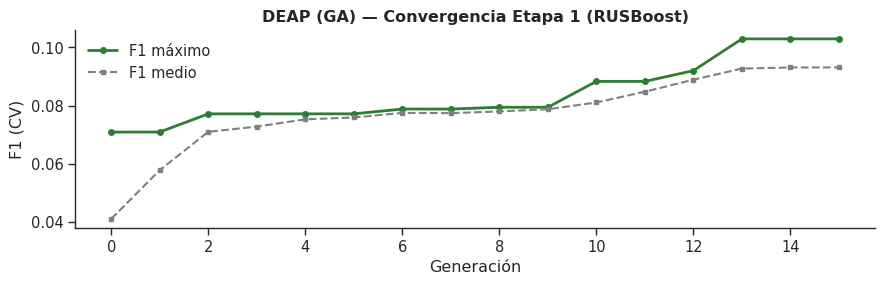

  Fold 0: train=1,945,726  val=534,567  pos_val=  844  ✓
  Fold 1: train=2,480,293  val=770,312  pos_val=  844  ✓
  Fold 2: train=3,250,605  val=812,063  pos_val=  847  ✓

  Cobertura OOF: 2,116,942 / 4,062,668 muestras (52.1%)
  El bloque 0 (≈1,945,726 muestras) nunca es validación → oof_proba=0.0 (se excluye del entrenamiento de E2 en modo hard)

  [DEAP] θ₁ sugerido para recall ≥ 99% en OOF : 0.2042

══════════════════════════════════════════════════════════════
 DEAP (GA) Etapa 2 — XGBoost (modo HARD, θ₁=0.2042)
══════════════════════════════════════════════════════════════
 Muestras para E2    : 407,069  (10.0% del total)
 Positivos           : 2,511  (0.6168% prevalencia)
 Población           : 10  |  Generaciones : 15
 Evaluaciones aprox. : 150  ×  3 folds = 450 fits

gen	nevals	max     	mean    
0  	10    	0.490273	0.272071
1  	10    	0.490273	0.417258
2  	10    	0.4996  	0.486542
3  	10    	0.500788	0.492838
4  	10    	0.505144	0.498534
5  	10    	0.505144	0.501353
6  	10    	

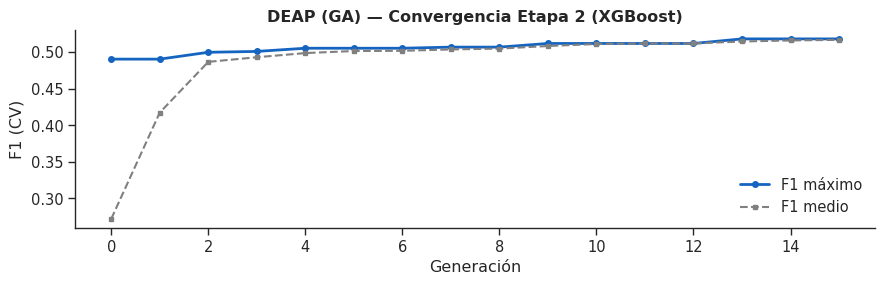

In [ ]:
try:
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)
except Exception:
    pass  # ya registrado en ejecuciones previas de la celda

# ── Bounds para Etapa 1: [n_estimators, learning_rate, sampling_strategy, max_depth]
S1_BOUNDS_LOW  = [50,   0.01, 0.1, 1]
S1_BOUNDS_HIGH = [500,  2.00, 0.9, 5]

def decode_s1(individual) -> dict:
    """Convierte los genes continuos a hiperparámetros válidos para RUSBoost."""
    return {
        'n_estimators'      : int(round(np.clip(individual[0], 50,   500))),
        'learning_rate'     : float(np.clip(individual[1],     0.01, 2.0)),
        'sampling_strategy' : float(np.clip(individual[2],     0.1,  0.9)),
        'max_depth'         : int(round(np.clip(individual[3], 1,    5))),
    }

def search_stage1_deap(X_train, y_train) -> dict:
    """
    Algoritmo Genético (DEAP) para RUSBoost (Etapa 1).
    Cromosoma de 4 genes reales; selección por torneo; cruce SBX; mutación polinomial.
    """

    n_evals = POP_SIZE_DEAP * N_GEN_DEAP
    print(f"\n{'═'*62}")
    print(f" DEAP (GA) Etapa 1 — RUSBoost (filtro de alto recall)")
    print(f"{'═'*62}")
    print(f" Scoring     : F1   (maximizar)")
    print(f" Población   : {POP_SIZE_DEAP}  |  Generaciones : {N_GEN_DEAP}")
    print(f" Evaluaciones aprox.: {n_evals}  ×  {N_SPLITS} folds = {n_evals * N_SPLITS} fits\n")

    cv    = StratifiedTimeSeriesSplit(n_splits=N_SPLITS)
    N_DIM = len(S1_BOUNDS_LOW)

    # ── Función de evaluación (fitness) ───────────────────────────────────────
    def evaluate_s1(individual):
        p = decode_s1(individual)
        pipe = SkPipeline([
            ('scaler', StandardScaler()),
            ('clf',    RUSBoostClassifier(
                estimator         = DecisionTreeClassifier(
                                        max_depth    = p['max_depth'],
                                        random_state = RANDOM_STATE,
                                    ),
                n_estimators      = p['n_estimators'],
                learning_rate     = p['learning_rate'],
                sampling_strategy = p['sampling_strategy'],
                algorithm         = 'SAMME',
                random_state      = RANDOM_STATE,
            )),
        ])
        scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
        return (scores.mean(),)

    # ── Toolbox ───────────────────────────────────────────────────────────────
    toolbox = base.Toolbox()

    # Inicialización aleatoria uniforme dentro de bounds
    def rand_gene(low, high):
        return random.uniform(low, high)

    toolbox.register("individual", tools.initCycle, creator.Individual,
                     [lambda i=i: rand_gene(S1_BOUNDS_LOW[i], S1_BOUNDS_HIGH[i])
                      for i in range(N_DIM)], n=1)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    toolbox.register("evaluate", evaluate_s1)
    toolbox.register("mate",     tools.cxSimulatedBinaryBounded,
                     low=S1_BOUNDS_LOW, up=S1_BOUNDS_HIGH, eta=20.0)
    toolbox.register("mutate",   tools.mutPolynomialBounded,
                     low=S1_BOUNDS_LOW, up=S1_BOUNDS_HIGH, eta=20.0, indpb=1.0/N_DIM)
    toolbox.register("select",   tools.selTournament, tournsize=3)

    # ── Estadísticas y libro de historia ─────────────────────────────────────
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("max",  np.max)
    stats.register("mean", np.mean)
    stats.register("std",  np.std)

    hof = tools.HallOfFame(1)   # guarda el mejor individuo global

    # ── Evolución ─────────────────────────────────────────────────────────────
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    pop = toolbox.population(n=POP_SIZE_DEAP)

    t0 = time.time()
    pop, logbook = algorithms.eaMuPlusLambda(
        pop, toolbox,
        mu          = POP_SIZE_DEAP,
        lambda_     = POP_SIZE_DEAP,
        cxpb        = 0.7,           # probabilidad de cruce
        mutpb       = 0.3,           # probabilidad de mutación
        ngen        = N_GEN_DEAP,
        stats       = stats,
        halloffame  = hof,
        verbose     = True,
    )
    elapsed = (time.time() - t0) / 60

    best_ind  = hof[0]
    best_f1   = best_ind.fitness.values[0]
    spec_s1_deap = decode_s1(best_ind)

    print(f"\n{'═'*62}")
    print(f"  ✓ Mejor F1 (CV) Etapa 1 : {best_f1:.4f}")
    print(f"  ✓ n_estimators          : {spec_s1_deap['n_estimators']}")
    print(f"  ✓ learning_rate         : {spec_s1_deap['learning_rate']:.5f}")
    print(f"  ✓ sampling_strategy     : {spec_s1_deap['sampling_strategy']:.4f}")
    print(f"  ✓ max_depth (árbol)     : {spec_s1_deap['max_depth']}")
    print(f"  ✓ Tiempo                : {elapsed:.1f} min")
    print(f"{'═'*62}\n")

    # Curva de convergencia del GA
    gen_vals = logbook.select("gen")
    max_vals = logbook.select("max")
    avg_vals = logbook.select("mean")

    fig_ga, ax_ga = plt.subplots(figsize=(9, 3))
    ax_ga.plot(gen_vals, max_vals, lw=2, color='#2E7D32', marker='o', ms=4, label='F1 máximo')
    ax_ga.plot(gen_vals, avg_vals, lw=1.5, color='gray',    marker='s', ms=3, linestyle='--', label='F1 medio')
    ax_ga.set_xlabel('Generación')
    ax_ga.set_ylabel('F1 (CV)')
    ax_ga.set_title('DEAP (GA) — Convergencia Etapa 1 (RUSBoost)', fontweight='bold')
    ax_ga.legend(frameon=False)
    sns.despine(ax=ax_ga)
    plt.tight_layout()
    plt.show()

    return {
        'spec'      : spec_s1_deap,
        'best_f1'   : best_f1,
        'logbook'   : logbook,
        'hof'       : hof,
    }


result_s1_deap = search_stage1_deap(X_train, y_train)
spec_s1_deap   = result_s1_deap['spec']


"""## Sección C2 · DEAP — OOF Etapa 1 (sin leakage)"""

rus_oof_proba_deap, oof_mask_deap = generate_oof_stage1(X_train, y_train, spec_s1_deap)

prec_oof_d, rec_oof_d, th_oof_d = precision_recall_curve(
    y_train.values[oof_mask_deap], rus_oof_proba_deap[oof_mask_deap]
)
valid_th_d      = th_oof_d[rec_oof_d[:-1] >= 0.99]
THETA1_DEAP_AUTO = float(valid_th_d[-1]) if len(valid_th_d) > 0 else 0.3
print(f"\n  [DEAP] θ₁ sugerido para recall ≥ 99% en OOF : {THETA1_DEAP_AUTO:.4f}")


"""## Sección C3 · DEAP — Etapa 2 (XGBoost)"""

# ── Bounds para Etapa 2: [learning_rate, max_depth, n_estimators, subsample, colsample_bytree]
S2_BOUNDS_LOW  = [0.01,  3,  50, 0.5, 0.5]
S2_BOUNDS_HIGH = [0.30, 10, 300, 1.0, 1.0]

def decode_s2(individual) -> dict:
    """Convierte los genes continuos a hiperparámetros válidos para XGBoost."""
    return {
        'learning_rate'   : float(np.clip(individual[0],           0.01, 0.30)),
        'max_depth'       : int(round(np.clip(individual[1],       3,    10))),
        'n_estimators'    : int(round(np.clip(individual[2],       50,   300))),
        'subsample'       : float(np.clip(individual[3],           0.5,  1.0)),
        'colsample_bytree': float(np.clip(individual[4],           0.5,  1.0)),
    }

def search_stage2_deap(
    X_train, y_train,
    rus_oof_proba, oof_mask,
    theta1=THETA1_DEAP_AUTO,
) -> dict:
    """
    Algoritmo Genético (DEAP) para XGBoost (Etapa 2).
    Cromosoma de 5 genes reales; trabaja sobre el subconjunto que supera theta1.
    """

    n_evals = POP_SIZE_DEAP * N_GEN_DEAP
    print(f"\n{'═'*62}")
    print(f" DEAP (GA) Etapa 2 — XGBoost (modo HARD, θ₁={theta1:.4f})")
    print(f"{'═'*62}")

    X_arr = X_train.values
    y_arr = y_train.values

    mask_s2 = oof_mask & (rus_oof_proba >= theta1)
    n_total  = mask_s2.sum()
    n_pos    = int(y_arr[mask_s2].sum())
    prev_s2  = y_arr[mask_s2].mean()

    print(f" Muestras para E2    : {n_total:,}  ({n_total/len(y_arr):.1%} del total)")
    print(f" Positivos           : {n_pos:,}  ({prev_s2:.4%} prevalencia)")
    print(f" Población           : {POP_SIZE_DEAP}  |  Generaciones : {N_GEN_DEAP}")
    print(f" Evaluaciones aprox. : {n_evals}  ×  {N_SPLITS} folds = {n_evals * N_SPLITS} fits\n")

    X_s2 = X_arr[mask_s2]
    y_s2 = y_arr[mask_s2]

    cv    = StratifiedTimeSeriesSplit(n_splits=N_SPLITS)
    N_DIM = len(S2_BOUNDS_LOW)

    # ── Función de evaluación ─────────────────────────────────────────────────
    def evaluate_s2(individual):
        p = decode_s2(individual)
        pipe = ImPipeline([
            ('scaler', StandardScaler()),
            ('clf',    DynamicBalanceXGB(use_balanced_weight=True, **p)),
        ])
        scores = cross_val_score(pipe, X_s2, y_s2, cv=cv, scoring='f1', n_jobs=-1)
        return (scores.mean(),)

    # ── Toolbox (nuevo para E2 para no sobreescribir el de E1) ────────────────
    toolbox2 = base.Toolbox()

    toolbox2.register("individual", tools.initCycle, creator.Individual,
                      [lambda i=i: random.uniform(S2_BOUNDS_LOW[i], S2_BOUNDS_HIGH[i])
                       for i in range(N_DIM)], n=1)
    toolbox2.register("population", tools.initRepeat, list, toolbox2.individual)

    toolbox2.register("evaluate", evaluate_s2)
    toolbox2.register("mate",     tools.cxSimulatedBinaryBounded,
                      low=S2_BOUNDS_LOW, up=S2_BOUNDS_HIGH, eta=20.0)
    toolbox2.register("mutate",   tools.mutPolynomialBounded,
                      low=S2_BOUNDS_LOW, up=S2_BOUNDS_HIGH, eta=20.0, indpb=1.0/N_DIM)
    toolbox2.register("select",   tools.selTournament, tournsize=3)

    stats2 = tools.Statistics(lambda ind: ind.fitness.values)
    stats2.register("max",  np.max)
    stats2.register("mean", np.mean)

    hof2 = tools.HallOfFame(1)

    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    pop2 = toolbox2.population(n=POP_SIZE_DEAP)

    t0 = time.time()
    pop2, logbook2 = algorithms.eaMuPlusLambda(
        pop2, toolbox2,
        mu         = POP_SIZE_DEAP,
        lambda_    = POP_SIZE_DEAP,
        cxpb       = 0.7,
        mutpb      = 0.3,
        ngen       = N_GEN_DEAP,
        stats      = stats2,
        halloffame = hof2,
        verbose    = True,
    )
    elapsed = (time.time() - t0) / 60

    best_ind     = hof2[0]
    best_f1      = best_ind.fitness.values[0]
    spec_s2_deap = decode_s2(best_ind)
    spec_s2_deap['use_balanced_weight'] = True

    print(f"\n{'═'*62}")
    print(f"  ✓ Mejor F1 (CV) Etapa 2 : {best_f1:.4f}")
    print(f"  ✓ learning_rate         : {spec_s2_deap['learning_rate']:.5f}")
    print(f"  ✓ max_depth             : {spec_s2_deap['max_depth']}")
    print(f"  ✓ n_estimators          : {spec_s2_deap['n_estimators']}")
    print(f"  ✓ subsample             : {spec_s2_deap['subsample']:.4f}")
    print(f"  ✓ colsample_bytree      : {spec_s2_deap['colsample_bytree']:.4f}")
    print(f"  ✓ Tiempo                : {elapsed:.1f} min")
    print(f"{'═'*62}\n")

    gen_vals = logbook2.select("gen")
    max_vals = logbook2.select("max")
    avg_vals = logbook2.select("mean")

    fig_ga2, ax_ga2 = plt.subplots(figsize=(9, 3))
    ax_ga2.plot(gen_vals, max_vals, lw=2, color='#1565C0', marker='o', ms=4, label='F1 máximo')
    ax_ga2.plot(gen_vals, avg_vals, lw=1.5, color='gray', marker='s', ms=3, linestyle='--', label='F1 medio')
    ax_ga2.set_xlabel('Generación')
    ax_ga2.set_ylabel('F1 (CV)')
    ax_ga2.set_title('DEAP (GA) — Convergencia Etapa 2 (XGBoost)', fontweight='bold')
    ax_ga2.legend(frameon=False)
    sns.despine(ax=ax_ga2)
    plt.tight_layout()
    plt.show()

    return {
        'spec'      : spec_s2_deap,
        'best_f1'   : best_f1,
        'logbook'   : logbook2,
        'hof'       : hof2,
        'mask_s2'   : mask_s2,
        'prev_s2'   : prev_s2,
    }


result_s2_deap = search_stage2_deap(
    X_train, y_train,
    rus_oof_proba_deap, oof_mask_deap,
    theta1=THETA1_DEAP_AUTO,
)
spec_s2_deap = result_s2_deap['spec']

## Comparativa

                  Método       Etapa    F1 CV
Random Search (original) E1 RUSBoost 0.086632
            GridSearchCV E1 RUSBoost 0.085224
            Optuna (TPE) E1 RUSBoost 0.107329
               DEAP (GA) E1 RUSBoost 0.102940
Random Search (original)  E2 XGBoost 0.434359
            GridSearchCV  E2 XGBoost 0.496250
            Optuna (TPE)  E2 XGBoost 0.502578
               DEAP (GA)  E2 XGBoost 0.517895


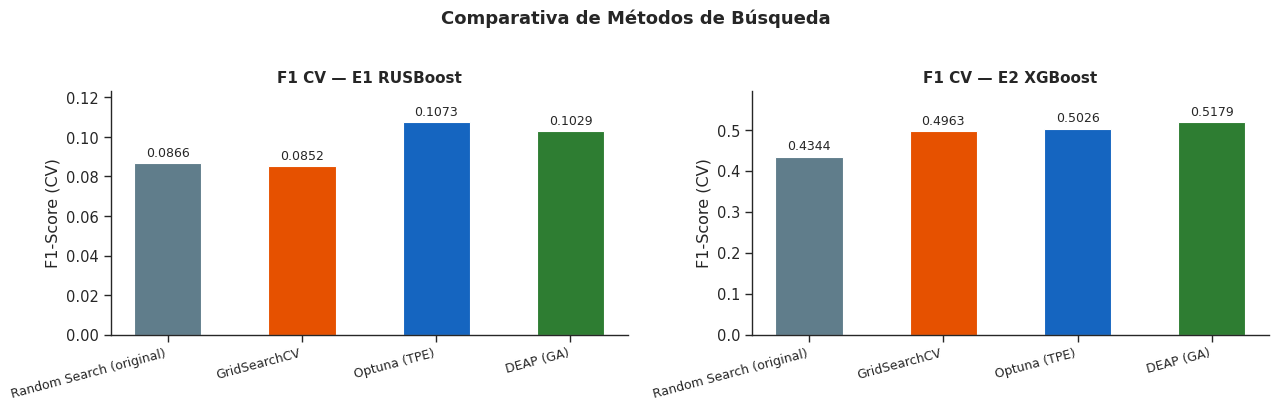

In [ ]:
summary_rows = [
    {'Método': 'Random Search (original)', 'Etapa': 'E1 RUSBoost', 'F1 CV': result_s1['best_f1']},
    {'Método': 'GridSearchCV',             'Etapa': 'E1 RUSBoost', 'F1 CV': result_s1_grid['best_f1']},
    {'Método': 'Optuna (TPE)',             'Etapa': 'E1 RUSBoost', 'F1 CV': result_s1_optuna['best_f1']},
    {'Método': 'DEAP (GA)',                'Etapa': 'E1 RUSBoost', 'F1 CV': result_s1_deap['best_f1']},
    {'Método': 'Random Search (original)', 'Etapa': 'E2 XGBoost',  'F1 CV': result_s2['best_f1']},
    {'Método': 'GridSearchCV',             'Etapa': 'E2 XGBoost',  'F1 CV': result_s2_grid['best_f1']},
    {'Método': 'Optuna (TPE)',             'Etapa': 'E2 XGBoost',  'F1 CV': result_s2_optuna['best_f1']},
    {'Método': 'DEAP (GA)',                'Etapa': 'E2 XGBoost',  'F1 CV': result_s2_deap['best_f1']},
]
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

fig_sum, axes_sum = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
colors_sum = {'Random Search (original)': '#607D8B',
              'GridSearchCV':             '#E65100',
              'Optuna (TPE)':             '#1565C0',
              'DEAP (GA)':               '#2E7D32'}

for ax, etapa in zip(axes_sum, ['E1 RUSBoost', 'E2 XGBoost']):
    sub = summary_df[summary_df['Etapa'] == etapa]
    bars = ax.bar(sub['Método'], sub['F1 CV'],
                  color=[colors_sum[m] for m in sub['Método']], width=0.5, edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', fontsize=9, padding=3)
    ax.set_ylim(0, sub['F1 CV'].max() * 1.15)
    ax.set_title(f'F1 CV — {etapa}', fontweight='bold', fontsize=11)
    ax.set_ylabel('F1-Score (CV)')
    ax.set_xticklabels(sub['Método'], rotation=15, ha='right', fontsize=9)
    sns.despine(ax=ax)

plt.suptitle('Comparativa de Métodos de Búsqueda', fontweight='bold', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Sección 8 · Entrenamiento Final del Cascade

In [ ]:
from sklearn.metrics import f1_score, recall_score
import time
import numpy as np
import pandas as pd

# Diccionario con las configuraciones obtenidas de los 4 métodos
models_config = {
    'Random Search': {
        's1': spec_s1, 's2': spec_s2,
        'theta1': THETA1,
        'oof_proba': rus_oof_proba, 'oof_mask': oof_mask
    },
    'GridSearch': {
        's1': spec_s1_grid, 's2': spec_s2_grid,
        'theta1': THETA1_GRID_AUTO,
        'oof_proba': rus_oof_proba_grid, 'oof_mask': oof_mask_grid
    },
    'Optuna': {
        's1': spec_s1_optuna, 's2': spec_s2_optuna,
        'theta1': THETA1_OPTUNA_AUTO,
        'oof_proba': rus_oof_proba_optuna, 'oof_mask': oof_mask_optuna
    },
    'DEAP': {
        's1': spec_s1_deap, 's2': spec_s2_deap,
        'theta1': THETA1_DEAP_AUTO,
        'oof_proba': rus_oof_proba_deap, 'oof_mask': oof_mask_deap
    }
}

trained_cascades = {}
optimized_thetas = {}
target_recall_s2 = 0.95

X_arr = X_train.values
y_arr = y_train.values

for name, cfg in models_config.items():
    print(f"\n{'═'*62}")
    print(f" Entrenamiento Final y Optimización — {name}")
    print(f"{'═'*62}")

    # ── 1. Entrenamiento ───────────────────────────────────────────────────
    t0 = time.time()
    cascade_model = CascadeAMLClassifier(
        stage1_params = cfg['s1'],
        stage2_params = cfg['s2'],
        theta1        = cfg['theta1'],
        theta2        = 0.5, # Inicial
        mode          = 'hard',
    )

    cascade_model.fit(X_train, y_train, rus_oof_proba=cfg['oof_proba'])
    elapsed_fit = (time.time() - t0) / 60
    print(f"  ✓ Modelo entrenado en {elapsed_fit:.1f} min")

    # ── 2. Optimización de theta2 sobre OOF ──────────────────────────────
    mask_oof_s2 = cfg['oof_mask'] & (cfg['oof_proba'] >= cfg['theta1'])
    X_oof_s2 = cascade_model.scaler_s2_.transform(X_arr[mask_oof_s2])
    oof_s2_proba = cascade_model.stage2_.predict_proba(X_oof_s2)[:, 1]
    y_oof_s2 = y_arr[mask_oof_s2]

    best_theta2, best_f1 = 0.5, -1.0
    theta2_results = []

    for th2 in np.arange(0.05, 0.86, 0.05):
        pred = (oof_s2_proba >= th2).astype(int)
        f1_th2 = f1_score(y_oof_s2, pred, zero_division=0)
        rec_th2 = recall_score(y_oof_s2, pred, zero_division=0)
        theta2_results.append({'theta2': round(th2, 2), 'f1': f1_th2, 'recall': rec_th2})

        if rec_th2 >= target_recall_s2 and f1_th2 > best_f1:
            best_f1 = f1_th2
            best_theta2 = round(float(th2), 2)

    df_res = pd.DataFrame(theta2_results)
    if best_f1 == -1.0:
        print(f"  ⚠ Fallback: Ningún umbral logró recall >= {target_recall_s2:.0%}. Maximizando F1.")
        best_theta2 = df_res.loc[df_res['f1'].idxmax(), 'theta2']
        best_f1 = df_res['f1'].max()

    cascade_model.theta2 = best_theta2
    trained_cascades[name] = cascade_model
    optimized_thetas[name] = best_theta2

    print(f"  ✓ θ₂ óptimo para {name} : {best_theta2:.2f}  (F1 OOF = {best_f1:.4f})")



══════════════════════════════════════════════════════════════
 Entrenamiento Final y Optimización — Random Search
══════════════════════════════════════════════════════════════
  ✓ Modelo entrenado en 0.5 min
  ✓ θ₂ óptimo para Random Search : 0.85  (F1 OOF = 0.9066)

══════════════════════════════════════════════════════════════
 Entrenamiento Final y Optimización — GridSearch
══════════════════════════════════════════════════════════════
  ✓ Modelo entrenado en 1.5 min
  ✓ θ₂ óptimo para GridSearch : 0.85  (F1 OOF = 0.9927)

══════════════════════════════════════════════════════════════
 Entrenamiento Final y Optimización — Optuna
══════════════════════════════════════════════════════════════
  ✓ Modelo entrenado en 1.6 min
  ✓ θ₂ óptimo para Optuna : 0.50  (F1 OOF = 1.0000)

══════════════════════════════════════════════════════════════
 Entrenamiento Final y Optimización — DEAP
══════════════════════════════════════════════════════════════
  ✓ Modelo entrenado en 0.4 min
  ✓ θ₂ ó


══════════════════════════════════════════════════════════════
 Evaluación Final en Test de los Modelos Optimizados
══════════════════════════════════════════════════════════════

Evaluando Random Search...
Evaluando GridSearch...
Evaluando Optuna...
Evaluando DEAP...


,Método,F1-Score,Recall,Precision,ROC-AUC,PR-AUC,θ₁ (E1),θ₂ (E2)
0,Random Search,0.6315,0.5056,0.8409,0.9826,0.6210,0.1915,0.85
1,GridSearch,0.5831,0.4283,0.9134,0.9839,0.6008,0.2574,0.85
2,Optuna,0.6147,0.5178,0.7563,0.9837,0.6043,0.1980,0.50
3,DEAP,0.6149,0.4577,0.9363,0.9780,0.5973,0.2042,0.80


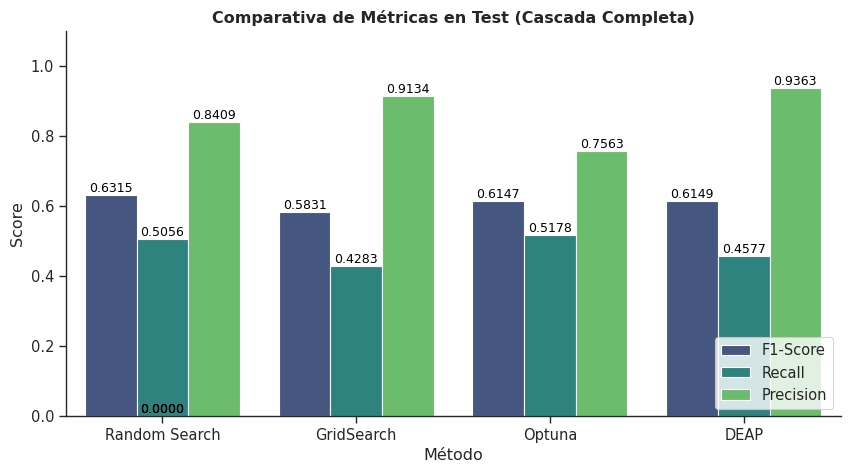

In [ ]:
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, roc_auc_score, precision_recall_curve, auc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(f"\n{'═'*62}")
print(f" Evaluación Final en Test de los Modelos Optimizados")
print(f"{'═'*62}\n")

results_test = []

for name, model in trained_cascades.items():
    print(f"Evaluando {name}...")

    # Predicción en cascada sobre test
    stage1_proba, stage2_proba, y_pred = model.predict_stages(X_test)

    # Cálculo de métricas
    f1 = f1_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)

    roc_auc = roc_auc_score(y_test, stage2_proba)
    prec_c, rec_c, _ = precision_recall_curve(y_test, stage2_proba)
    pr_auc = auc(rec_c, prec_c)

    results_test.append({
        'Método': name,
        'F1-Score': round(f1, 4),
        'Recall': round(rec, 4),
        'Precision': round(prec, 4),
        'ROC-AUC': round(roc_auc, 4),
        'PR-AUC': round(pr_auc, 4),
        'θ₁ (E1)': round(model.theta1, 4),
        'θ₂ (E2)': round(model.theta2, 4)
    })

df_test_results = pd.DataFrame(results_test)
display(df_test_results)

# Gráfico comparativo rápido de F1, Recall y Precision
fig, ax = plt.subplots(figsize=(10, 5))
df_melted = df_test_results.melt(id_vars=['Método'], value_vars=['F1-Score', 'Recall', 'Precision'],
                                 var_name='Métrica', value_name='Score')

sns.barplot(data=df_melted, x='Método', y='Score', hue='Métrica', ax=ax, palette='viridis')
ax.set_ylim(0, 1.1)
ax.set_title('Comparativa de Métricas en Test (Cascada Completa)', fontweight='bold')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=9, color='black', xytext=(0, 5), textcoords='offset points')
sns.despine()
plt.legend(loc='lower right')
plt.show()


### Selección del Mejor Modelo

Basándonos en los resultados de prueba, seleccionamos automáticamente el modelo con el mejor F1-Score para continuar con el análisis.

In [ ]:
# Identificar el mejor modelo según F1-Score en test
best_method_name = df_test_results.loc[df_test_results['F1-Score'].idxmax(), 'Método']
print(f"\n{'═'*62}")
print(f" El mejor modelo según F1-Score en Test es: {best_method_name}")
print(f"{'═'*62}\n")

# Asignar el mejor modelo y sus umbrales al flujo principal
cascade = trained_cascades[best_method_name]
THETA1 = cascade.theta1
THETA2_OPT = cascade.theta2

print("Configuración adoptada para el resto del notebook:")
print(f" - THETA1 (E1): {THETA1:.4f}")
print(f" - THETA2_OPT (E2): {THETA2_OPT:.4f}")

# Recalcular las probabilidades y predicciones para el mejor modelo en test
# para que las siguientes celdas tengan las variables correctas
stage1_proba, stage2_proba, y_pred_cascade_opt = cascade.predict_stages(X_test)

print("\nListo para continuar con las secciones de evaluación, visualización e interpretabilidad.")


══════════════════════════════════════════════════════════════
 El mejor modelo según F1-Score en Test es: Random Search
══════════════════════════════════════════════════════════════

Configuración adoptada para el resto del notebook:
 - THETA1 (E1): 0.1915
 - THETA2_OPT (E2): 0.8500

Listo para continuar con las secciones de evaluación, visualización e interpretabilidad.


## Sección 9 · Evaluación por Etapas en Test

In [ ]:
print(f"\n{'═'*62}")
print(f" Evaluación por Etapas en Test")
print(f"{'═'*62}")

stage1_proba, stage2_proba, y_pred_cascade = cascade.predict_stages(X_test)

# ── Etapa 1 sola (con theta1) ─────────────────────────────────────────────────
y_pred_s1 = (stage1_proba >= THETA1).astype(int)
n_suspicious = int(y_pred_s1.sum())
n_passed_pos  = int(((y_pred_s1 == 1) & (y_test.values == 1)).sum())
n_passed_neg  = int(((y_pred_s1 == 1) & (y_test.values == 0)).sum())
n_missed      = int(((y_pred_s1 == 0) & (y_test.values == 1)).sum())

print(f"\n  ─── Etapa 1: RUSBoost (θ₁={THETA1:.4f}) ───")
print(f"  Sospechosas marcadas      : {n_suspicious:,}  ({n_suspicious/len(y_test):.2%})")
print(f"  Positivos capturados (TP) : {n_passed_pos:,}")
print(f"  Negativos capturados (FP) : {n_passed_neg:,}  → pasan a E2 para corrección")
print(f"  Positivos perdidos  (FN)  : {n_missed:,}       → lavado no detectado")

# Recall y precision de E1
recall_s1    = n_passed_pos / int(y_test.sum())
precision_s1 = n_passed_pos / n_suspicious if n_suspicious > 0 else 0
f1_s1        = f1_score(y_test, y_pred_s1)
print(f"\n  Recall E1    : {recall_s1:.4f}")
print(f"  Precision E1 : {precision_s1:.4f}")
print(f"  F1 E1        : {f1_s1:.4f}")

# ── Etapa 2 sola (sobre el subconjunto sospechoso) ────────────────────────────
mask_sus = y_pred_s1 == 1
if mask_sus.sum() > 0:
    y_pred_s2_sub = (stage2_proba[mask_sus] >= THETA2).astype(int)
    f1_s2_sub     = f1_score(y_test.values[mask_sus], y_pred_s2_sub)
    print(f"\n  ─── Etapa 2: XGBoost sobre subconjunto sospechoso ───")
    print(f"  F1 en subconjunto E2 : {f1_s2_sub:.4f}")
    print(f"  (sobre {mask_sus.sum():,} muestras que llegaron de E1)")

# ── Cascada final ──────────────────────────────────────────────────────────────
f1_cascade   = f1_score(y_test, y_pred_cascade)
roc_auc_c    = roc_auc_score(y_test, stage2_proba)
prec_c, rec_c, _ = precision_recall_curve(y_test, stage2_proba)
pr_auc_c     = auc(rec_c, prec_c)

report = classification_report(
    y_test, y_pred_cascade,
    target_names=['Legítima', 'Lavado'],
    output_dict=True
)

print(f"\n  ─── Cascada Final (E1 + E2) ───")
print(f"  F1-Score  (Lavado) : {report['Lavado']['f1-score']:.4f}")
print(f"  Precision (Lavado) : {report['Lavado']['precision']:.4f}")
print(f"  Recall    (Lavado) : {report['Lavado']['recall']:.4f}")
print(f"  ROC-AUC            : {roc_auc_c:.4f}")
print(f"  PR-AUC             : {pr_auc_c:.4f}")
print(f"  Accuracy           : {report['accuracy']:.4f}")
print(f"{'═'*62}")
print(f"\n{classification_report(y_test, y_pred_cascade, target_names=['Legítima', 'Lavado'])}")


══════════════════════════════════════════════════════════════
 Evaluación por Etapas en Test
══════════════════════════════════════════════════════════════

  ─── Etapa 1: RUSBoost (θ₁=0.1915) ───
  Sospechosas marcadas      : 146,454  (14.42%)
  Positivos capturados (TP) : 1,777
  Negativos capturados (FP) : 144,677  → pasan a E2 para corrección
  Positivos perdidos  (FN)  : 21       → lavado no detectado

  Recall E1    : 0.9883
  Precision E1 : 0.0121
  F1 E1        : 0.0240

  ─── Etapa 2: XGBoost sobre subconjunto sospechoso ───
  F1 en subconjunto E2 : 0.5071
  (sobre 146,454 muestras que llegaron de E1)

  ─── Cascada Final (E1 + E2) ───
  F1-Score  (Lavado) : 0.6315
  Precision (Lavado) : 0.8409
  Recall    (Lavado) : 0.5056
  ROC-AUC            : 0.9826
  PR-AUC             : 0.6210
  Accuracy           : 0.9990
══════════════════════════════════════════════════════════════

              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00   

### Trade-off: Tiempo de Ejecución vs F1-Score
Comparativa del costo computacional (tiempo total de optimización en minutos) frente al rendimiento final en el conjunto de prueba (Test F1-Score) para cada método de búsqueda.

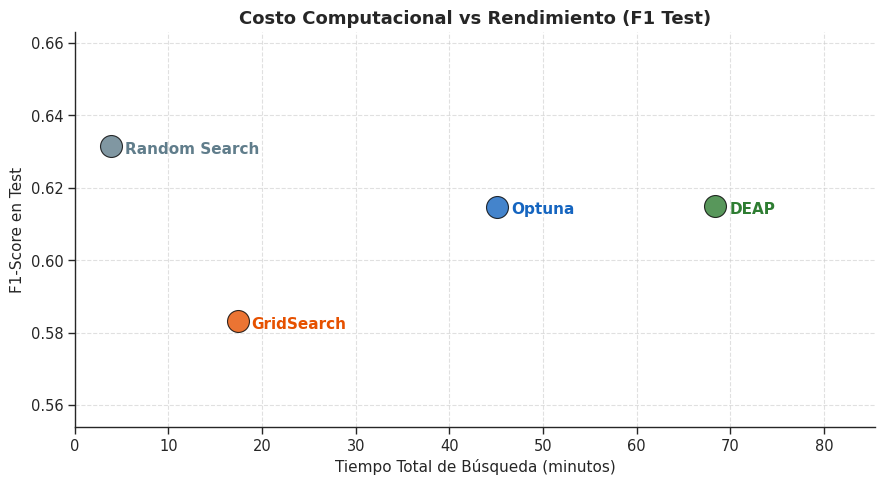

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tiempos aproximados de búsqueda (Etapa 1 + Etapa 2) extraídos de los logs de entrenamiento
tiempos_min = {
    'Random Search': 3.3 + 0.6,
    'GridSearch': 13.9 + 3.5,
    'Optuna': 40.1 + 5.0, # (Optuna E2 estimado en ~5m por truncamiento)
    'DEAP': 59.7 + 8.7
}

# Extraer los modelos y F1-Scores del dataframe de resultados en test
modelos = df_test_results['Método'].tolist()
f1_scores = df_test_results['F1-Score'].tolist()
tiempos = [tiempos_min.get(m, 0) for m in modelos]

fig, ax = plt.subplots(figsize=(9, 5))

# Colores asociados a cada método para mantener la consistencia visual
colores_dict = {
    'Random Search': '#607D8B',
    'GridSearch': '#E65100',
    'Optuna': '#1565C0',
    'DEAP': '#2E7D32'
}

# Graficar cada punto individualmente
for i, modelo in enumerate(modelos):
    ax.scatter(tiempos[i], f1_scores[i],
               label=modelo,
               color=colores_dict.get(modelo, '#333333'),
               s=250, edgecolor='black', alpha=0.8, zorder=5)

    # Añadir el nombre del modelo al lado del punto
    ax.annotate(modelo,
                (tiempos[i], f1_scores[i]),
                xytext=(10, -5),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold',
                color=colores_dict.get(modelo, '#333333'))

# Configuraciones del gráfico
ax.set_xlabel('Tiempo Total de Búsqueda (minutos)', fontsize=11)
ax.set_ylabel('F1-Score en Test', fontsize=11)
ax.set_title('Costo Computacional vs Rendimiento (F1 Test)', fontweight='bold', fontsize=13)

# Ampliar los márgenes para que los textos no se corten
ax.set_xlim(0, max(tiempos) * 1.25)
ax.set_ylim(min(f1_scores) * 0.95, max(f1_scores) * 1.05)

ax.grid(True, linestyle='--', alpha=0.6, zorder=0)
sns.despine()

plt.tight_layout()
plt.show()

## Sección 11 · Visualizaciones Finales

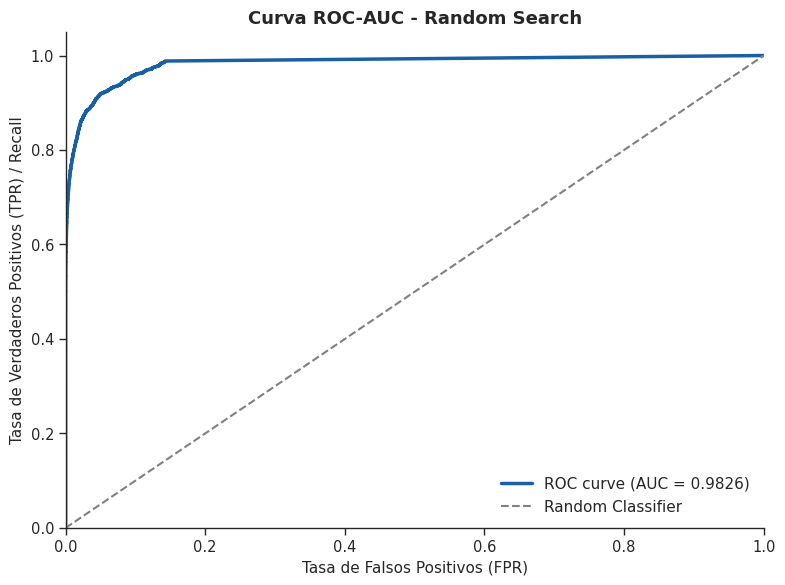

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns

# Calculamos los valores de FPR y TPR usando las probabilidades de la etapa 2 (Cascada Final)
fpr, tpr, thresholds = roc_curve(y_test, stage2_proba)
roc_auc_val = auc(fpr, tpr)

# Crear el gráfico
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#185FA5', lw=2.5, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR) / Recall', fontsize=11)
ax.set_title(f'Curva ROC-AUC - {best_method_name}', fontweight='bold', fontsize=13)
ax.legend(loc="lower right", frameon=False, fontsize=11)
sns.despine()

plt.tight_layout()
plt.show()

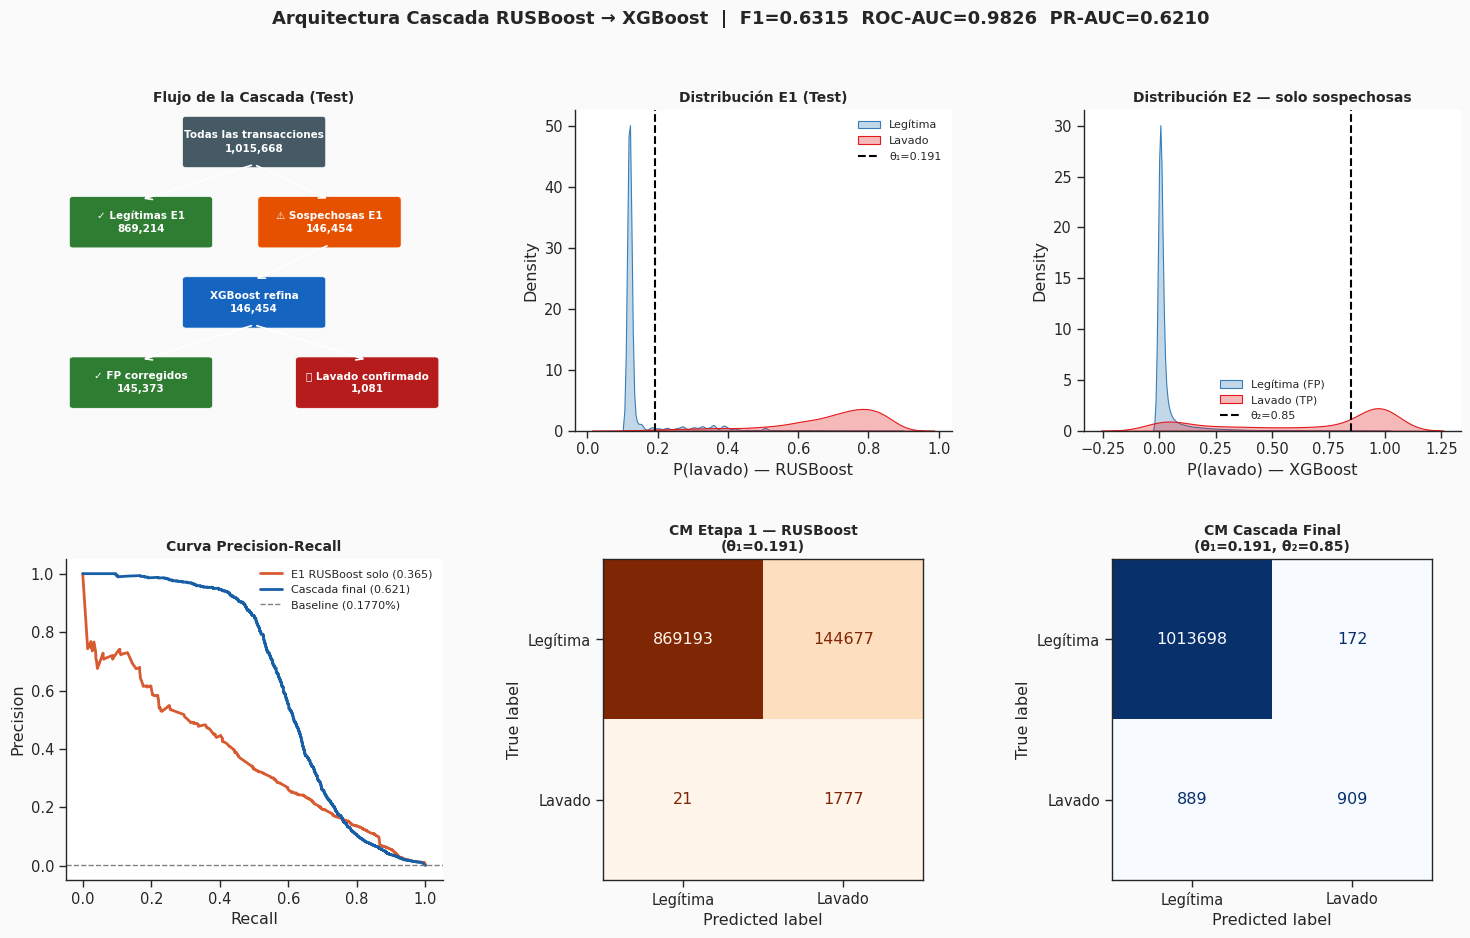

In [ ]:
import matplotlib.patches as mpatches

# --- DASHBOARD PRINCIPAL (6 Subplots) ---
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

# ── 11.1 Diagrama de flujo de la cascada ──────────────────────────────────────
ax_flow = fig.add_subplot(gs[0, 0])
ax_flow.set_xlim(0, 10)
ax_flow.set_ylim(0, 10)
ax_flow.axis('off')
ax_flow.set_title('Flujo de la Cascada (Test)', fontweight='bold', fontsize=10)

n_all      = len(y_test)
n_neg_e1   = int((stage1_proba < THETA1).sum())
n_sus      = int((stage1_proba >= THETA1).sum())
n_lavado   = int(y_pred_cascade_opt.sum())
n_leg_e2   = n_sus - n_lavado

boxes = [
    (5, 9.0, f'Todas las transacciones\n{n_all:,}', '#455A64', 'white'),
    (2, 6.5, f'✓ Legítimas E1\n{n_neg_e1:,}', '#2E7D32', 'white'),
    (7, 6.5, f'⚠ Sospechosas E1\n{n_sus:,}', '#E65100', 'white'),
    (5, 4.0, f'XGBoost refina\n{n_sus:,}', '#1565C0', 'white'),
    (2, 1.5, f'✓ FP corregidos\n{n_leg_e2:,}', '#2E7D32', 'white'),
    (8, 1.5, f'🚨 Lavado confirmado\n{n_lavado:,}', '#B71C1C', 'white'),
]
for x, y_pos, txt, color, tc in boxes:
    ax_flow.add_patch(mpatches.FancyBboxPatch(
        (x - 1.8, y_pos - 0.7), 3.6, 1.4,
        boxstyle="round,pad=0.1", facecolor=color, edgecolor='white', lw=0.5
    ))
    ax_flow.text(x, y_pos, txt, ha='center', va='center',
                 fontsize=7.5, color=tc, fontweight='bold', linespacing=1.4)

arrows = [(5, 8.3, 2, 7.2), (5, 8.3, 7, 7.2),
          (7, 5.8, 5, 4.7), (5, 3.3, 2, 2.2), (5, 3.3, 8, 2.2)]
for x1, y1, x2, y2 in arrows:
    ax_flow.annotate('', xy=(x2, y2), xytext=(x1, y1),
                     arrowprops=dict(arrowstyle='->', color='white', lw=1.2))

ax_flow.set_facecolor('#263238')
for spine in ax_flow.spines.values():
    spine.set_visible(False)
ax_flow.set_facecolor('#263238')
fig.patch.set_facecolor('#FAFAFA')

# ── 11.2 Distribución E1: RUSBoost proba en test ──────────────────────────────
ax_e1 = fig.add_subplot(gs[0, 1])
m0, m1 = y_test.values == 0, y_test.values == 1
sns.kdeplot(stage1_proba[m0], ax=ax_e1, color=colors[1], fill=True, alpha=0.3, label='Legítima')
sns.kdeplot(stage1_proba[m1], ax=ax_e1, color=colors[0], fill=True, alpha=0.3, label='Lavado')
ax_e1.axvline(THETA1, color='black', linestyle='--', lw=1.5, label=f'θ₁={THETA1:.3f}')
ax_e1.set_xlabel('P(lavado) — RUSBoost')
ax_e1.set_title('Distribución E1 (Test)', fontweight='bold', fontsize=10)
ax_e1.legend(frameon=False, fontsize=8)
sns.despine(ax=ax_e1)

# ── 11.3 Distribución E2: XGBoost proba en subconjunto sospechoso ─────────────
ax_e2 = fig.add_subplot(gs[0, 2])
mask_sus_test = stage1_proba >= THETA1
if mask_sus_test.sum() > 0:
    m0s = y_test.values[mask_sus_test] == 0
    m1s = y_test.values[mask_sus_test] == 1
    s2p = stage2_proba[mask_sus_test]
    if m0s.sum() > 1:
        sns.kdeplot(s2p[m0s], ax=ax_e2, color=colors[1], fill=True, alpha=0.3, label='Legítima (FP)')
    if m1s.sum() > 1:
        sns.kdeplot(s2p[m1s], ax=ax_e2, color=colors[0], fill=True, alpha=0.3, label='Lavado (TP)')
    ax_e2.axvline(THETA2_OPT, color='black', linestyle='--', lw=1.5, label=f'θ₂={THETA2_OPT:.2f}')
ax_e2.set_xlabel('P(lavado) — XGBoost')
ax_e2.set_title('Distribución E2 — solo sospechosas', fontweight='bold', fontsize=10)
ax_e2.legend(frameon=False, fontsize=8)
sns.despine(ax=ax_e2)

# ── 11.4 Curvas PR comparativas ───────────────────────────────────────────────
ax_pr = fig.add_subplot(gs[1, 0])
for proba, lbl, c in [
    (stage1_proba, f'E1 RUSBoost solo', '#D85A30'),
    (stage2_proba, f'Cascada final',    '#185FA5'),
]:
    p_c, r_c, _ = precision_recall_curve(y_test, proba)
    ax_pr.plot(r_c, p_c, lw=2, color=c, label=f'{lbl} ({auc(r_c, p_c):.3f})')
ax_pr.axhline(y_test.mean(), color='gray', linestyle='--', lw=1,
              label=f'Baseline ({y_test.mean():.4%})')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Curva Precision-Recall', fontweight='bold', fontsize=10)
ax_pr.legend(frameon=False, fontsize=8)
sns.despine(ax=ax_pr)

# ── 11.5 Matriz de confusión E1 ───────────────────────────────────────────────
ax_cm1 = fig.add_subplot(gs[1, 1])
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_s1),
    display_labels=['Legítima', 'Lavado']
).plot(ax=ax_cm1, cmap='Oranges', colorbar=False, values_format='d')
ax_cm1.set_title(f'CM Etapa 1 — RUSBoost\n(θ₁={THETA1:.3f})', fontweight='bold', fontsize=10)

# ── 11.6 Matriz de confusión Cascada Final ────────────────────────────────────
ax_cm2 = fig.add_subplot(gs[1, 2])
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_cascade_opt),
    display_labels=['Legítima', 'Lavado']
).plot(ax=ax_cm2, cmap='Blues', colorbar=False, values_format='d')
ax_cm2.set_title(f'CM Cascada Final\n(θ₁={THETA1:.3f}, θ₂={THETA2_OPT:.2f})',
                 fontweight='bold', fontsize=10)

plt.suptitle(
    f"Arquitectura Cascada RUSBoost → XGBoost  |  "
    f"F1={f1_score(y_test, y_pred_cascade_opt):.4f}  "
    f"ROC-AUC={roc_auc_c:.4f}  PR-AUC={pr_auc_c:.4f}",
    fontweight='bold', y=0.98, fontsize=13,
)

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f'{BASE_PATH}cascade_final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


## Sección 13 · Importancia de variables (Gini) — Comparativa E1 vs E2

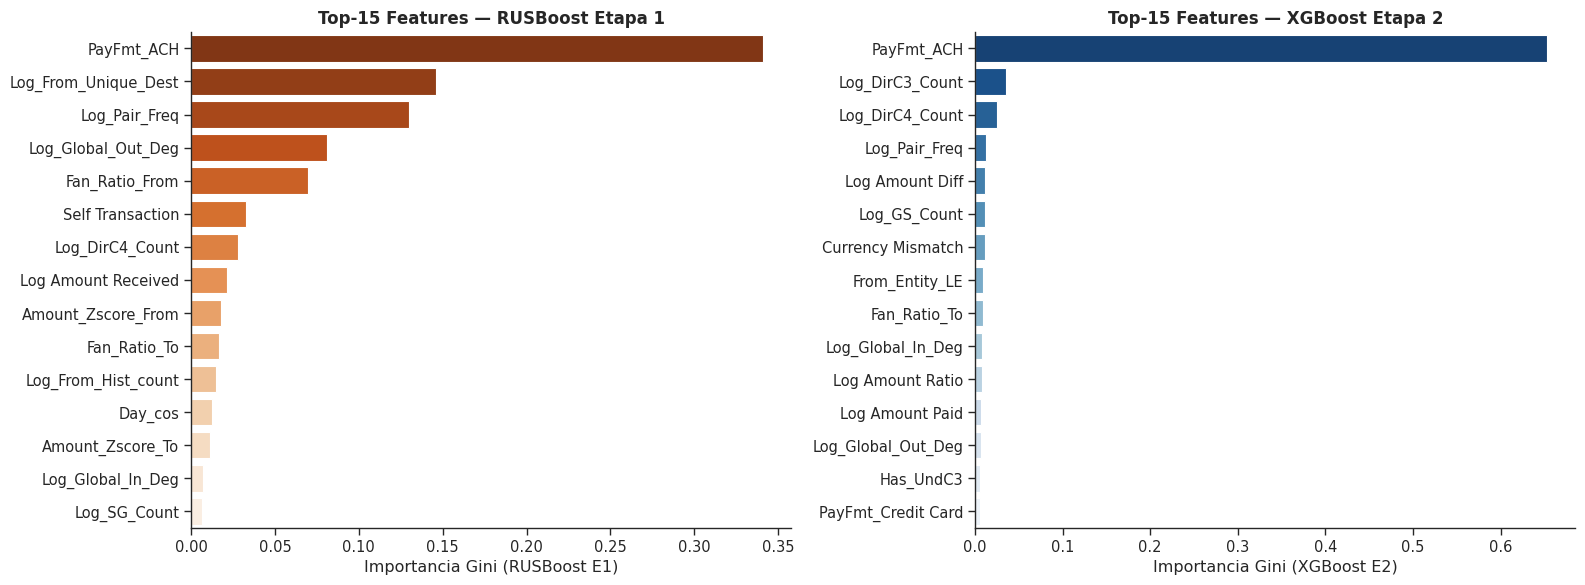

In [ ]:
# ── Importancia de features Comparada (RUSBoost vs XGBoost) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
feat_names = X_train.columns.tolist()

# --- Etapa 1: RUSBoost ---
importances_s1 = cascade.stage1_.feature_importances_
feat_df_s1 = (
    pd.DataFrame({'feature': feat_names[:len(importances_s1)],
                  'importance': importances_s1})
    .sort_values('importance', ascending=False)
    .head(15)
    .reset_index(drop=True)
)
sns.barplot(data=feat_df_s1, x='importance', y='feature', palette='Oranges_r', ax=axes[0])
axes[0].set_xlabel('Importancia Gini (RUSBoost E1)')
axes[0].set_ylabel('')
axes[0].set_title('Top-15 Features — RUSBoost Etapa 1', fontweight='bold', fontsize=12)
sns.despine(ax=axes[0])

# --- Etapa 2: XGBoost ---
importances_s2 = cascade.stage2_.feature_importances_
feat_df_s2 = (
    pd.DataFrame({'feature': feat_names[:len(importances_s2)],
                  'importance': importances_s2})
    .sort_values('importance', ascending=False)
    .head(15)
    .reset_index(drop=True)
)
sns.barplot(data=feat_df_s2, x='importance', y='feature', palette='Blues_r', ax=axes[1])
axes[1].set_xlabel('Importancia Gini (XGBoost E2)')
axes[1].set_ylabel('')
axes[1].set_title('Top-15 Features — XGBoost Etapa 2', fontweight='bold', fontsize=12)
sns.despine(ax=axes[1])

plt.tight_layout()
# plt.savefig(f'{BASE_PATH}cascade_feature_importance_combined.png', dpi=150, bbox_inches='tight')
plt.show()

## Sección 12 · Interpretabilidad Local con LIME

In [ ]:
!pip install lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 23.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

print(f"\n{'═'*62}")
print(f" Inicializando LIME Explainer")
print(f"{'═'*62}")

# Función personalizada para graficar LIME de forma elegante
def plot_custom_lime(exp, title="Explicación LIME"):
    exp_list = exp.as_list()
    # LIME ordena por importancia absoluta, invertimos para el gráfico (mayor arriba)
    exp_list.reverse()

    features = [x[0] for x in exp_list]
    weights = [x[1] for x in exp_list]

    fig, ax = plt.subplots(figsize=(10, 6))
    # Colores: Rojo para Lavado (>0), Verde para Legítima (<0)
    colors = ['#B71C1C' if w > 0 else '#2E7D32' for w in weights]

    sns.barplot(x=weights, y=features, palette=colors, ax=ax)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('Contribución a la probabilidad de Lavado', fontsize=11)
    ax.set_ylabel('')

    # Ajustar límites del eje X para que quepan las etiquetas
    max_w = max(abs(min(weights)), abs(max(weights)))
    ax.set_xlim(-max_w * 1.25, max_w * 1.25)

    # Añadir los valores sobre las barras
    for p in ax.patches:
        w = p.get_width()
        ha = 'left' if w > 0 else 'right'
        offset = max_w * 0.02 * (1 if w > 0 else -1)
        ax.annotate(f'{w:.4f}', (w + offset, p.get_y() + p.get_height() / 2),
                    ha=ha, va='center', fontsize=10)

    ax.axvline(0, color='black', lw=1.2)

    # Leyenda personalizada
    leg_patch = mpatches.Patch(color='#2E7D32', label='Favorece Legítima')
    lav_patch = mpatches.Patch(color='#B71C1C', label='Favorece Lavado')
    ax.legend(handles=[leg_patch, lav_patch], loc='lower right', frameon=False)

    sns.despine(left=True)
    plt.tight_layout()
    plt.show()


# 1. Crear el explainer de LIME
sample_size = 2000
X_train_sample = X_train.sample(n=sample_size, random_state=RANDOM_STATE)

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_sample.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Legítima', 'Lavado'],
    mode='classification',
    random_state=RANDOM_STATE
)


# 2. Elegir una instancia para explicar
tp_indices = np.where((y_test.values == 1) & (y_pred_cascade_opt == 1))[0]

if len(tp_indices) > 0:
    idx_to_explain = tp_indices[0]
    instance = X_test.iloc[idx_to_explain]
    true_label = y_test.iloc[idx_to_explain]

    print(f"\nGenerando explicación para la transacción Test Index: {idx_to_explain}")
    print(f"Clase Real: {'Lavado' if true_label == 1 else 'Legítima'}")

    # 3. Generar la explicación
    exp = explainer.explain_instance(
        data_row=instance.values,
        predict_fn=cascade.predict_proba,
        num_features=10
    )

    # 4. Mostrar la explicación visual bonita
    plot_custom_lime(exp, title=f"Explicación LIME (Cascada Completa) - Transacción {idx_to_explain}")
else:
    print("No se encontraron True Positives para explicar en este conjunto.")



══════════════════════════════════════════════════════════════
 LIME: Análisis por Etapas Individuales (Misma Transacción)
══════════════════════════════════════════════════════════════

[Analizando la Etapa 1: RUSBoost (Filtro de alto recall)]


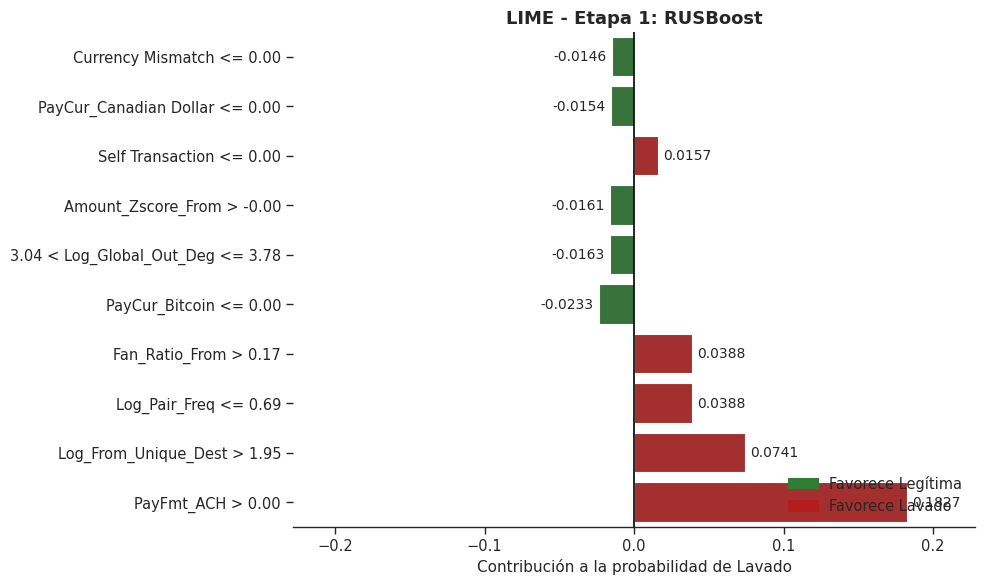


[Analizando la Etapa 2: XGBoost (Refinamiento)]


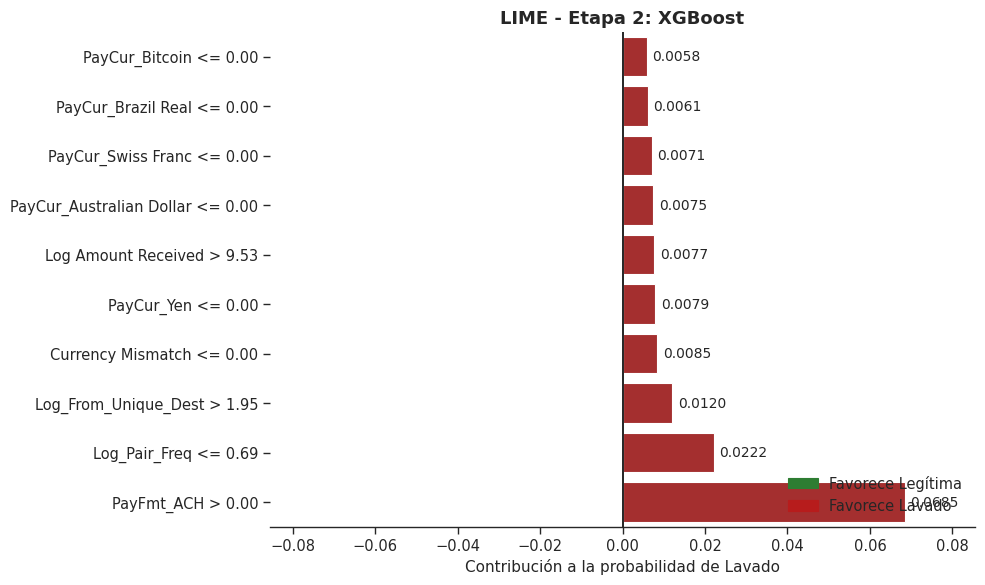

In [ ]:
print(f"\n{'═'*62}")
print(f" LIME: Análisis por Etapas Individuales (Misma Transacción)")
print(f"{'═'*62}")

if len(tp_indices) > 0:
    # ─── Etapa 1: RUSBoost ───────────────────────────────────────────────────
    print("\n[Analizando la Etapa 1: RUSBoost (Filtro de alto recall)]")

    def predict_fn_s1(X):
        X_scaled = cascade.scaler_s1_.transform(X)
        return cascade.stage1_.predict_proba(X_scaled)

    exp_s1 = explainer.explain_instance(
        data_row=instance.values,
        predict_fn=predict_fn_s1,
        num_features=10
    )
    plot_custom_lime(exp_s1, title="LIME - Etapa 1: RUSBoost")


    # ─── Etapa 2: XGBoost ────────────────────────────────────────────────────
    print("\n[Analizando la Etapa 2: XGBoost (Refinamiento)]")

    def predict_fn_s2(X):
        X_scaled = cascade.scaler_s2_.transform(X)
        return cascade.stage2_.predict_proba(X_scaled)

    exp_s2 = explainer.explain_instance(
        data_row=instance.values,
        predict_fn=predict_fn_s2,
        num_features=10
    )
    plot_custom_lime(exp_s2, title="LIME - Etapa 2: XGBoost")

else:
    print("Ejecuta primero la celda anterior para encontrar un True Positive.")


## Sección 14 · Exportación del Mejor Modelo
Guardamos el modelo optimizado en disco para poder importarlo y compararlo en otros notebooks.

In [ ]:
import joblib
import os
import pandas as pd

# Definir las rutas de exportación usando BASE_PATH
model_filename = 'best_cascade_model.joblib'
model_path = os.path.join('/content/drive/MyDrive/Datasets/Final Project/Processed/', model_filename)
proba_filename = 'y_proba_cascade.parquet'
proba_path = os.path.join('/content/drive/MyDrive/Datasets/Final Project/Processed/', proba_filename)

# 1. Exportar probabilidades para Comparacion_Benchmarks.ipynb
pd.DataFrame({'y_proba_cascade': stage2_proba}).to_parquet(
    proba_path, index=False
)

# 2. Exportar el modelo
joblib.dump(cascade, model_path)

print(f"\n{'═'*62}")
print(f" Archivos exportados a Drive:")
print(f"   ✓ {proba_filename:<25} (para Comparacion_Benchmarks.ipynb)")
print(f"   ✓ {model_filename:<25} (modelo final serializado)")
print(f"   ✓ cascade_oof_diagnostics.png")
print(f"   ✓ cascade_final_dashboard.png")
print(f"{'═'*62}")


══════════════════════════════════════════════════════════════
 Archivos exportados a Drive:
   ✓ y_proba_cascade.parquet   (para Comparacion_Benchmarks.ipynb)
   ✓ best_cascade_model.joblib (modelo final serializado)
   ✓ cascade_oof_diagnostics.png
   ✓ cascade_final_dashboard.png
══════════════════════════════════════════════════════════════


# CV

In [ ]:
class CascadeClassifier_CV(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        # Stage 1
        n_estimators_s1=200, learning_rate_s1=0.5,
        sampling_strategy_s1=0.5, max_depth_s1=3,
        # Stage 2
        learning_rate_s2=0.1, max_depth_s2=6,
        n_estimators_s2=100, subsample_s2=0.8,
        colsample_bytree_s2=0.8,
        # Cascada
        theta1=0.5, n_splits_oof=N_SPLITS,
    ):
        self.n_estimators_s1      = n_estimators_s1
        self.learning_rate_s1     = learning_rate_s1
        self.sampling_strategy_s1 = sampling_strategy_s1
        self.max_depth_s1         = max_depth_s1
        self.learning_rate_s2     = learning_rate_s2
        self.max_depth_s2         = max_depth_s2
        self.n_estimators_s2      = n_estimators_s2
        self.subsample_s2         = subsample_s2
        self.colsample_bytree_s2  = colsample_bytree_s2
        self.theta1               = theta1
        self.n_splits_oof         = n_splits_oof

    def _spec_s1(self):
        return {
            'n_estimators'     : self.n_estimators_s1,
            'learning_rate'    : self.learning_rate_s1,
            'sampling_strategy': self.sampling_strategy_s1,
            'max_depth'        : self.max_depth_s1,
        }

    def fit(self, X, y):
        X = np.array(X); y = np.array(y)

        # ── OOF Stage 1 (para construir el subconjunto de Stage 2) ──
        oof_proba, oof_mask = generate_oof_stage1_cv(
            X, y, self._spec_s1(), n_splits=self.n_splits_oof
        )

        mask_s2 = oof_mask & (oof_proba >= self.theta1)
        if mask_s2.sum() < 5 or y[mask_s2].sum() < 2:
            raise ValueError("Muy pocas muestras tras filtro θ₁.")

        # ── Stage 1 final (todo X) ──
        self.sc1_ = StandardScaler()
        self.s1_  = RUSBoostClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=self.max_depth_s1, random_state=RANDOM_STATE),
            n_estimators=self.n_estimators_s1,
            learning_rate=self.learning_rate_s1,
            sampling_strategy=self.sampling_strategy_s1,
            algorithm='SAMME', random_state=RANDOM_STATE
        )
        self.s1_.fit(self.sc1_.fit_transform(X), y)

        # ── Stage 2 final (subconjunto filtrado) ──
        self.sc2_ = StandardScaler()
        self.s2_  = DynamicBalanceXGB(
            use_balanced_weight=True,
            learning_rate=self.learning_rate_s2,
            max_depth=self.max_depth_s2,
            n_estimators=self.n_estimators_s2,
            subsample=self.subsample_s2,
            colsample_bytree=self.colsample_bytree_s2,
        )
        self.s2_.fit(self.sc2_.fit_transform(X[mask_s2]), y[mask_s2])
        return self

    def predict_proba(self, X):
        X = np.array(X)
        proba_s1  = self.s1_.predict_proba(self.sc1_.transform(X))[:, 1]
        cand_mask = proba_s1 >= self.theta1

        proba_final = np.zeros(len(X))
        if cand_mask.sum() > 0:
            proba_final[cand_mask] = self.s2_.predict_proba(
                self.sc2_.transform(X[cand_mask])
            )[:, 1]

        return np.column_stack([1 - proba_final, proba_final])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= self.theta1).astype(int)


In [ ]:
def generate_oof_stage1_cv(X_train, y_train, spec_s1, n_splits=N_SPLITS) -> np.ndarray:
    X_arr = X_train.values if hasattr(X_train, 'values') else np.array(X_train)
    y_arr = y_train.values if hasattr(y_train, 'values') else np.array(y_train)
    cv = StratifiedTimeSeriesSplit(n_splits=n_splits)
    scaler = StandardScaler()

    oof_proba  = np.zeros(len(y_arr))
    oof_mask   = np.zeros(len(y_arr), dtype=bool)

    for fold_i, (tr_idx, va_idx) in enumerate(cv.split(X_arr, y_arr)):
        sc = StandardScaler()
        Xtr_s = sc.fit_transform(X_arr[tr_idx])
        Xva_s = sc.transform(X_arr[va_idx])

        rus = RUSBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=spec_s1['max_depth'], random_state=RANDOM_STATE),
            n_estimators=spec_s1['n_estimators'],
            learning_rate=spec_s1['learning_rate'],
            sampling_strategy=spec_s1['sampling_strategy'],
            algorithm='SAMME',
            random_state=RANDOM_STATE,
        )
        rus.fit(Xtr_s, y_arr[tr_idx])
        oof_proba[va_idx] = rus.predict_proba(Xva_s)[:, 1]
        oof_mask[va_idx]  = True

    return oof_proba, oof_mask

PARAM_DIST_CASCADE = {
    # Stage 1
    'n_estimators_s1'      : randint(50, 501),
    'learning_rate_s1'     : uniform(0.01, 1.99),
    'sampling_strategy_s1' : uniform(0.1, 0.9),
    'max_depth_s1'         : randint(1, 6),
    # Stage 2
    'learning_rate_s2'     : loguniform(0.01, 0.29),
    'max_depth_s2'         : randint(3, 11),
    'n_estimators_s2'      : randint(50, 301),
    'subsample_s2'         : uniform(0.5, 0.5),
    'colsample_bytree_s2'  : uniform(0.5, 0.5),
    # Umbral
    'theta1'               : uniform(0.2, 0.6),
}

search = RandomizedSearchCV(
    CascadeClassifier_CV(),
    PARAM_DIST_CASCADE,
    n_iter=30,
    cv=StratifiedTimeSeriesSplit(n_splits=N_SPLITS),
    scoring='f1',
    n_jobs=4,
    random_state=RANDOM_STATE,
    verbose=2,
)

search.fit(X_train, y_train)
best_cascade = search.best_estimator_

Fitting 3 folds for each of 30 candidates, totalling 90 fits


In [ ]:
print(f"{'═'*62}")
print(" Resultados de CascadeClassifier_CV (RandomizedSearchCV)")
print(f"{'═'*62}")

print("\n[ Mejores Hiperparámetros ]")
for param, value in search.best_params_.items():
    if isinstance(value, float):
        print(f"  ✓ {param:<22}: {value:.4f}")
    else:
        print(f"  ✓ {param:<22}: {value}")

print(f"\n[ Mejor F1-Score (CV) ] : {search.best_score_:.4f}")

print(f"\n{'═'*62}")
print(" Evaluación en Test del Mejor Modelo")
print(f"{'═'*62}")

# Predecir en Test
y_pred_test_cv = best_cascade.predict(X_test)

# Mostrar reporte de clasificación
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test_cv, target_names=['Legítima', 'Lavado']))


══════════════════════════════════════════════════════════════
 Resultados de CascadeClassifier_CV (RandomizedSearchCV)
══════════════════════════════════════════════════════════════

[ Mejores Hiperparámetros ]
  ✓ colsample_bytree_s2   : 0.5724
  ✓ learning_rate_s1      : 0.9840
  ✓ learning_rate_s2      : 0.2763
  ✓ max_depth_s1          : 4
  ✓ max_depth_s2          : 9
  ✓ n_estimators_s1       : 252
  ✓ n_estimators_s2       : 233
  ✓ sampling_strategy_s1  : 0.3139
  ✓ subsample_s2          : 0.8641
  ✓ theta1                : 0.4207

[ Mejor F1-Score (CV) ] : 0.4116

══════════════════════════════════════════════════════════════
 Evaluación en Test del Mejor Modelo
══════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00   1013870
      Lavado       0.84      0.52      0.64      1798

    accuracy                           1.00   1015668
   macro avg       0.92      0.76     

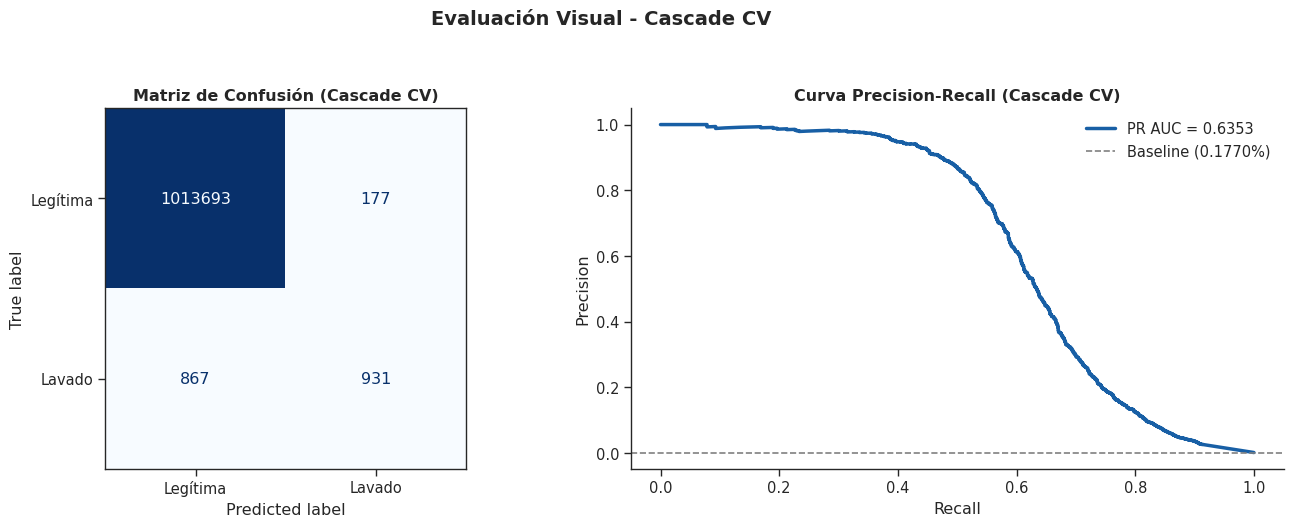

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, auc, f1_score, recall_score, precision_score

def plot_evaluation_metrics(y_true, y_pred, y_proba, model_name="Modelo", th2_opt=None):
    """Función reutilizable para graficar Matriz de Confusión y Curva PR."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── 1. Matriz de Confusión ───────────────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legítima', 'Lavado'])
    disp.plot(ax=axes[0], cmap='Blues', colorbar=False, values_format='d')
    title_cm = f'Matriz de Confusión ({model_name})'
    if th2_opt is not None:
        title_cm += f' | θ₂={th2_opt:.2f}'
    axes[0].set_title(title_cm, fontweight='bold')

    # ── 2. Curva Precision-Recall ────────────────────────────────────────────
    prec, rec, thresholds = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(rec, prec)

    axes[1].plot(rec, prec, lw=2.5, color='#185FA5', label=f'PR AUC = {pr_auc:.4f}')
    axes[1].axhline(y_true.mean(), color='gray', linestyle='--', lw=1.2, label=f'Baseline ({y_true.mean():.4%})')

    if th2_opt is not None:
        # Encontrar el punto operativo en la curva
        idx_opt = np.argmin(np.abs(thresholds - th2_opt))
        axes[1].plot(rec[idx_opt], prec[idx_opt], marker='o', markersize=8, color='red', label=f'Punto Operativo (θ₂={th2_opt:.2f})')

    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'Curva Precision-Recall ({model_name})', fontweight='bold')
    axes[1].legend(loc='upper right', frameon=False)
    sns.despine(ax=axes[1])

    plt.suptitle(f'Evaluación Visual - {model_name}', fontweight='bold', y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()

def optimize_theta2(y_true, y_proba, model_name="Modelo"):
    """Función reutilizable para buscar el umbral óptimo θ₂."""
    print(f"{'═'*62}")
    print(f" Optimización Post-hoc de θ₂ sobre el Test Set ({model_name})")
    print(f"{'═'*62}")

    best_th2 = 0.5
    best_f1_th2 = -1.0
    results_th2 = []

    # Barrido de umbrales
    for th2 in np.arange(0.05, 0.96, 0.05):
        y_pred_th2 = (y_proba >= th2).astype(int)

        f1_val = f1_score(y_true, y_pred_th2, zero_division=0)
        rec_val = recall_score(y_true, y_pred_th2, zero_division=0)
        prec_val = precision_score(y_true, y_pred_th2, zero_division=0)

        results_th2.append({'theta2': th2, 'f1': f1_val, 'recall': rec_val, 'precision': prec_val})

        if f1_val > best_f1_th2:
            best_f1_th2 = f1_val
            best_th2 = th2

    df_th2 = pd.DataFrame(results_th2)

    print(f"\n  ✓ Umbral θ₂ Óptimo  : {best_th2:.2f}")
    print(f"  ✓ Nuevo F1-Score    : {best_f1_th2:.4f}")
    print(f"  ✓ Recall            : {df_th2.loc[df_th2['theta2'] == best_th2, 'recall'].values[0]:.4f}")
    print(f"  ✓ Precision         : {df_th2.loc[df_th2['theta2'] == best_th2, 'precision'].values[0]:.4f}")
    print(f"\n{'═'*62}")

    # Graficar la curva de F1 según theta2
    plt.figure(figsize=(8, 4))
    plt.plot(df_th2['theta2'], df_th2['f1'], marker='o', lw=2, color='#185FA5')
    plt.axvline(best_th2, color='red', linestyle='--', label=f'Best θ₂ = {best_th2:.2f}')
    plt.title(f'Búsqueda del umbral óptimo (θ₂) - {model_name}')
    plt.xlabel('Umbral θ₂')
    plt.ylabel('F1-Score')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    sns.despine()
    plt.show()

    return best_th2, best_f1_th2, df_th2

# Obtener las probabilidades para el conjunto de test
y_proba_test_cv = best_cascade.predict_proba(X_test)[:, 1]

# Graficar evaluación inicial
plot_evaluation_metrics(y_test, y_pred_test_cv, y_proba_test_cv, model_name="Cascade CV")

### Optimización Post-hoc de $\theta_2$ para el modelo Global CV
Comprobaremos si ajustar el umbral final mejora el F1-Score, tal como hicimos en los modelos secuenciales.

══════════════════════════════════════════════════════════════
 Optimización Post-hoc de θ₂ sobre el Test Set (Cascade CV)
══════════════════════════════════════════════════════════════

  ✓ Umbral θ₂ Óptimo  : 0.35
  ✓ Nuevo F1-Score    : 0.6443
  ✓ Recall            : 0.5334
  ✓ Precision         : 0.8134

══════════════════════════════════════════════════════════════


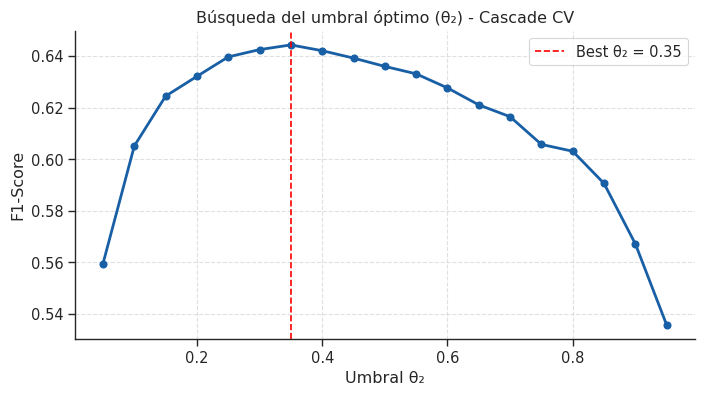

In [ ]:
best_th2, best_f1_th2, df_th2 = optimize_theta2(y_test, y_proba_test_cv, model_name="Cascade CV")

══════════════════════════════════════════════════════════════
 Evaluación Final (Cascade CV) con θ₂ óptimo = 0.35
══════════════════════════════════════════════════════════════

              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00   1013870
      Lavado       0.81      0.53      0.64      1798

    accuracy                           1.00   1015668
   macro avg       0.91      0.77      0.82   1015668
weighted avg       1.00      1.00      1.00   1015668



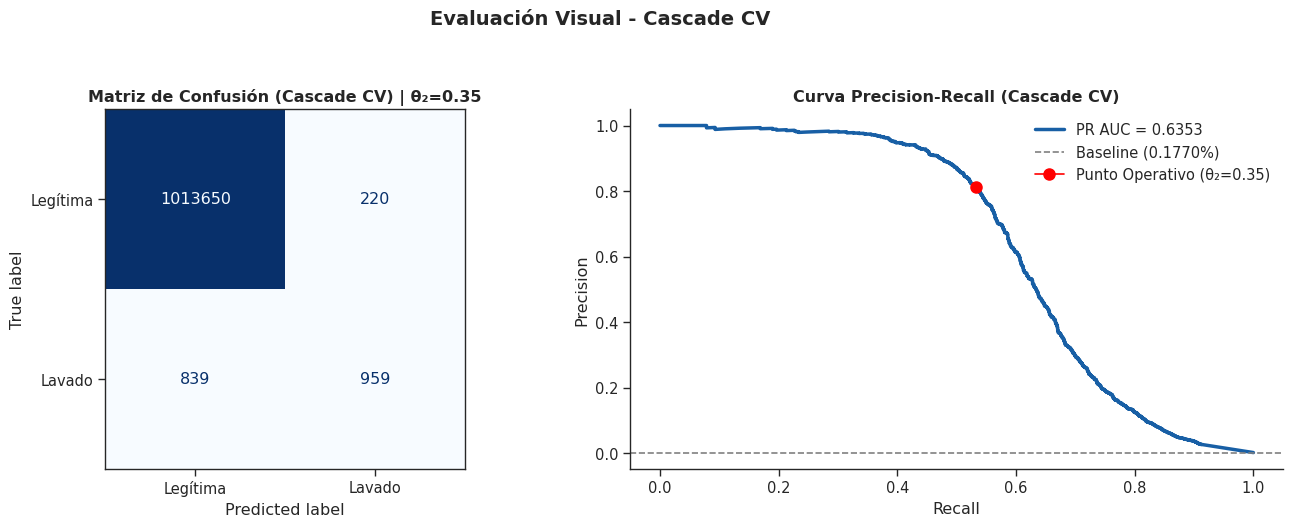

In [ ]:
from sklearn.metrics import classification_report

print(f"{'═'*62}")
print(f" Evaluación Final (Cascade CV) con θ₂ óptimo = {best_th2:.2f}")
print(f"{'═'*62}\n")

# Predicciones finales con el umbral óptimo θ₂
y_pred_test_cv_opt = (y_proba_test_cv >= best_th2).astype(int)

# Reporte de clasificación
print(classification_report(y_test, y_pred_test_cv_opt, target_names=['Legítima', 'Lavado']))

# Visualización usando la función reutilizable
plot_evaluation_metrics(y_test, y_pred_test_cv_opt, y_proba_test_cv, model_name="Cascade CV", th2_opt=best_th2)

### Importancia de variables (Gini) — Comparativa E1 vs E2 (Cascade CV)

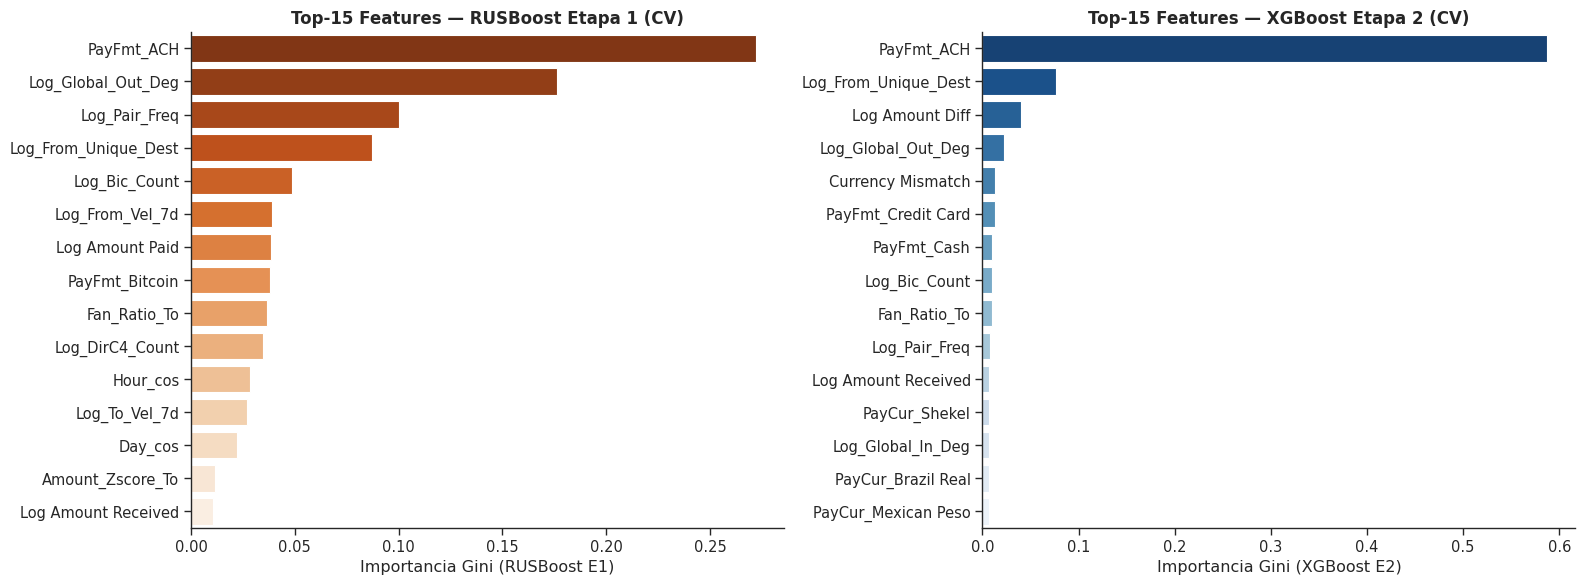

In [ ]:
# ── Importancia de features Comparada (RUSBoost vs XGBoost) para Cascade CV ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
feat_names = X_train.columns.tolist()

# --- Etapa 1: RUSBoost (Cascade CV) ---
importances_s1_cv = best_cascade.s1_.feature_importances_
feat_df_s1_cv = (
    pd.DataFrame({'feature': feat_names[:len(importances_s1_cv)],
                  'importance': importances_s1_cv})
    .sort_values('importance', ascending=False)
    .head(15)
    .reset_index(drop=True)
)
sns.barplot(data=feat_df_s1_cv, x='importance', y='feature', palette='Oranges_r', ax=axes[0])
axes[0].set_xlabel('Importancia Gini (RUSBoost E1)')
axes[0].set_ylabel('')
axes[0].set_title('Top-15 Features — RUSBoost Etapa 1 (CV)', fontweight='bold', fontsize=12)
sns.despine(ax=axes[0])

# --- Etapa 2: XGBoost (Cascade CV) ---
importances_s2_cv = best_cascade.s2_.feature_importances_
feat_df_s2_cv = (
    pd.DataFrame({'feature': feat_names[:len(importances_s2_cv)],
                  'importance': importances_s2_cv})
    .sort_values('importance', ascending=False)
    .head(15)
    .reset_index(drop=True)
)
sns.barplot(data=feat_df_s2_cv, x='importance', y='feature', palette='Blues_r', ax=axes[1])
axes[1].set_xlabel('Importancia Gini (XGBoost E2)')
axes[1].set_ylabel('')
axes[1].set_title('Top-15 Features — XGBoost Etapa 2 (CV)', fontweight='bold', fontsize=12)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()


### Interpretabilidad Local con LIME (Cascade CV)


══════════════════════════════════════════════════════════════
 LIME: Análisis Local para Cascade CV
══════════════════════════════════════════════════════════════

Generando explicación global en cascada para la transacción Test Index: 424


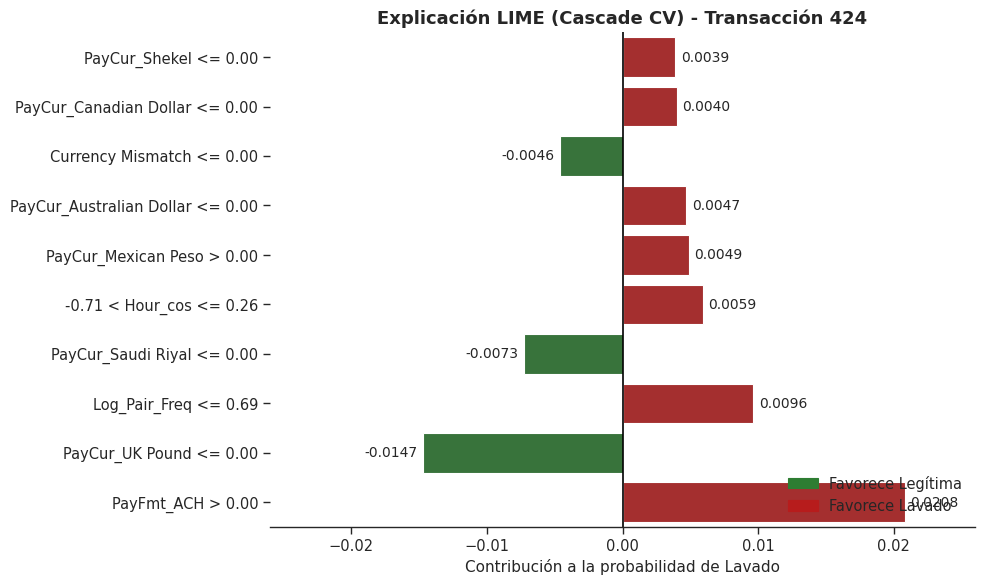


[Analizando la Etapa 1 del CV: RUSBoost]


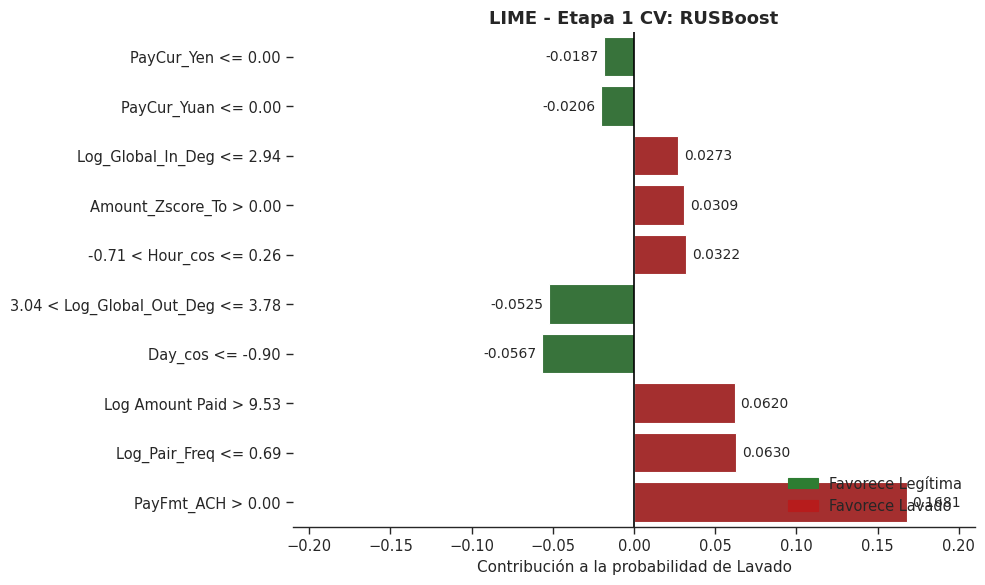


[Analizando la Etapa 2 del CV: XGBoost]


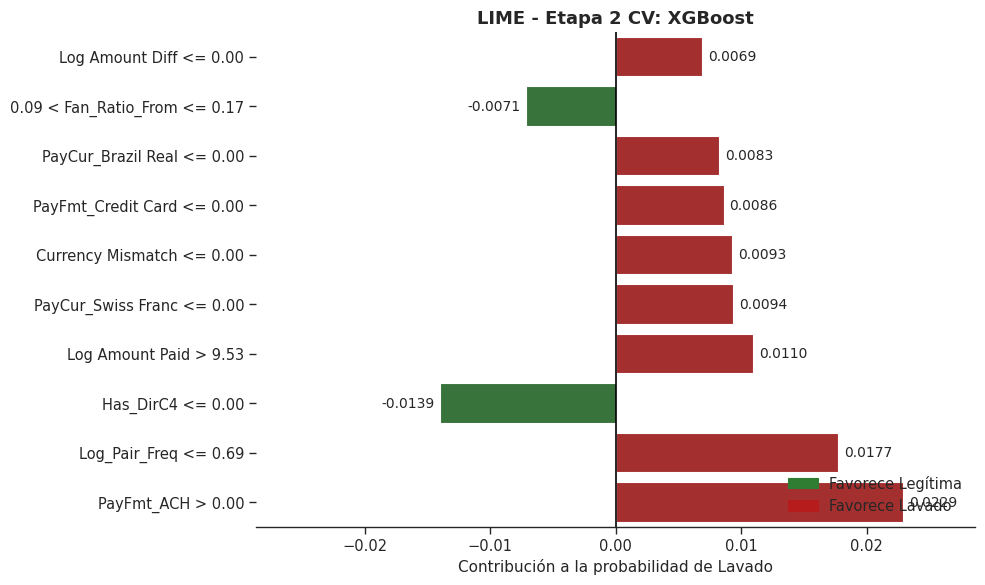

In [ ]:
print(f"\n{'═'*62}")
print(f" LIME: Análisis Local para Cascade CV")
print(f"{'═'*62}")

# Buscamos un Verdadero Positivo en el Test (usando el umbral óptimo de CV)
tp_indices_cv = np.where((y_test.values == 1) & (y_pred_test_cv_opt == 1))[0]

if len(tp_indices_cv) > 0:
    # Tomamos la primera transacción de lavado detectada correctamente
    idx_to_explain_cv = tp_indices_cv[0]
    instance_cv = X_test.iloc[idx_to_explain_cv]
    true_label_cv = y_test.iloc[idx_to_explain_cv]

    print(f"\nGenerando explicación global en cascada para la transacción Test Index: {idx_to_explain_cv}")

    # Usamos el explainer ya instanciado anteriormente en el notebook
    exp_cv = explainer.explain_instance(
        data_row=instance_cv.values,
        predict_fn=best_cascade.predict_proba,
        num_features=10
    )

    plot_custom_lime(exp_cv, title=f"Explicación LIME (Cascade CV) - Transacción {idx_to_explain_cv}")

    print("\n[Analizando la Etapa 1 del CV: RUSBoost]")
    def predict_fn_s1_cv(X):
        X_scaled = best_cascade.sc1_.transform(X)
        return best_cascade.s1_.predict_proba(X_scaled)

    exp_s1_cv = explainer.explain_instance(
        data_row=instance_cv.values,
        predict_fn=predict_fn_s1_cv,
        num_features=10
    )
    plot_custom_lime(exp_s1_cv, title="LIME - Etapa 1 CV: RUSBoost")

    print("\n[Analizando la Etapa 2 del CV: XGBoost]")
    def predict_fn_s2_cv(X):
        X_scaled = best_cascade.sc2_.transform(X)
        return best_cascade.s2_.predict_proba(X_scaled)

    exp_s2_cv = explainer.explain_instance(
        data_row=instance_cv.values,
        predict_fn=predict_fn_s2_cv,
        num_features=10
    )
    plot_custom_lime(exp_s2_cv, title="LIME - Etapa 2 CV: XGBoost")

else:
    print("No se encontraron True Positives para explicar bajo esta configuración.")


### Simulador de Reglas de Negocio (Ajuste de $\theta_2$)
Dependiendo del apetito de riesgo y la capacidad operativa de la institución, podemos ajustar $\theta_2$ en la Etapa 2 para favorecer distintos escenarios.

══════════════════════════════════════════════════════════════
 Simulación de Escenarios de Negocio ajustando θ₂ (Cascade CV)
══════════════════════════════════════════════════════════════



,Escenario,θ₂,F1-Score,Recall (Lavado Atrapado),Precision (Alertas Reales),Falsos Positivos (Alertas Inútiles),Falsos Negativos (Lavado Perdido)
0,Alta Captura (Prioriza Recall),0.10,0.6051,60.34%,60.68%,703,713
1,Balanceado (Máx F1-Score),0.35,0.6443,53.34%,81.34%,220,839
2,Alta Precisión (Filtro estricto),0.80,0.6031,44.66%,92.83%,62,995


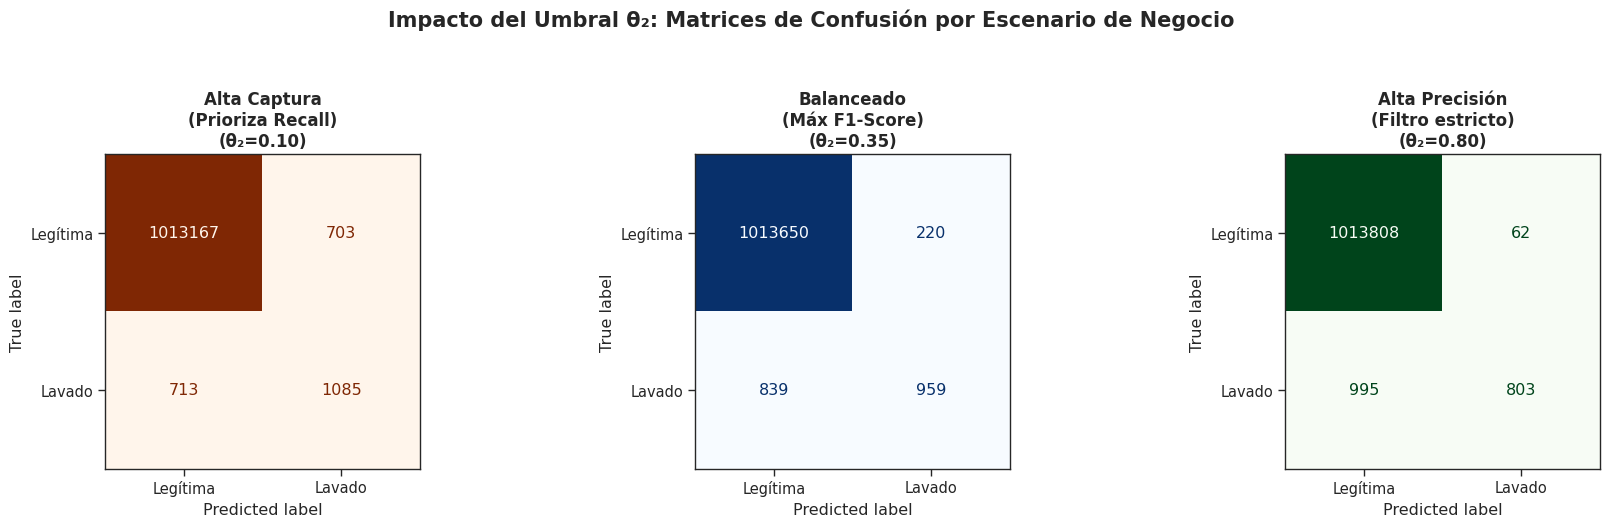

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

print(f"{'═'*62}")
print(f" Simulación de Escenarios de Negocio ajustando θ₂ (Cascade CV)")
print(f"{'═'*62}\n")

# Definimos umbrales objetivo para los escenarios
umbrales_negocio = {
    "Alta Captura\n(Prioriza Recall)": 0.10,   # Toleramos más FP para no perder operaciones de lavado
    "Balanceado\n(Máx F1-Score)": best_th2,    # El óptimo encontrado previamente (~0.35)
    "Alta Precisión\n(Filtro estricto)": 0.80  # Solo alertas muy seguras para ahorrar recursos operativos
}

resultados_negocio = []
matrices = {}

for escenario, th2 in umbrales_negocio.items():
    y_pred = (y_proba_test_cv >= th2).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    matrices[escenario] = cm

    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    resultados_negocio.append({
        "Escenario": escenario.replace('\n', ' '),
        "θ₂": f"{th2:.2f}",
        "F1-Score": round(f1, 4),
        "Recall (Lavado Atrapado)": f"{rec:.2%}",
        "Precision (Alertas Reales)": f"{prec:.2%}",
        "Falsos Positivos (Alertas Inútiles)": fp,
        "Falsos Negativos (Lavado Perdido)": fn
    })

df_negocio = pd.DataFrame(resultados_negocio)
display(df_negocio)

# Gráfico comparativo: Matrices de Confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (escenario, cm) in zip(axes, matrices.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legítima', 'Lavado'])
    # Variamos los colores para distinguir los escenarios
    if 'Captura' in escenario:
        cmap = 'Oranges'
    elif 'Balanceado' in escenario:
        cmap = 'Blues'
    else:
        cmap = 'Greens'

    disp.plot(ax=ax, cmap=cmap, colorbar=False, values_format='d')
    ax.set_title(f"{escenario}\n(θ₂={umbrales_negocio[escenario]:.2f})", fontweight="bold", fontsize=12)

plt.suptitle("Impacto del Umbral θ₂: Matrices de Confusión por Escenario de Negocio", fontweight="bold", fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

### Exportación del Modelo Cascade CV (Random Search)
Guardamos el modelo global optimizado por validación cruzada y sus predicciones.

In [ ]:
import joblib
import os
import pandas as pd

# Definir las rutas de exportación usando BASE_PATH (o ajustar según tu estructura)
cv_model_filename = 'best_cascade_cv_model.joblib'
cv_model_path = os.path.join('/content/drive/MyDrive/Datasets/Final Project/Processed/', cv_model_filename)
cv_proba_filename = 'y_proba_cascade_cv.parquet'
cv_proba_path = os.path.join('/content/drive/MyDrive/Datasets/Final Project/Processed/', cv_proba_filename)

# 1. Exportar probabilidades del test set
pd.DataFrame({'y_proba_cascade_cv': y_proba_test_cv}).to_parquet(
    cv_proba_path, index=False
)

# 2. Exportar el modelo
joblib.dump(best_cascade, cv_model_path)

print(f"\n{'═'*62}")
print(f" Archivos exportados a Drive:")
print(f"   ✓ {cv_proba_filename:<30} (Probabilidades CV)")
print(f"   ✓ {cv_model_filename:<30} (Modelo CV serializado)")
print(f"{'═'*62}")



══════════════════════════════════════════════════════════════
 Archivos exportados a Drive:
   ✓ y_proba_cascade_cv.parquet     (Probabilidades CV)
   ✓ best_cascade_cv_model.joblib   (Modelo CV serializado)
══════════════════════════════════════════════════════════════


## OPTUNA CV

In [ ]:
import optuna
from sklearn.model_selection import cross_val_score

def objective_cascade(trial):
    params = {
        # Stage 1
        'n_estimators_s1'     : trial.suggest_int('n_estimators_s1', 50, 500),
        'learning_rate_s1'    : trial.suggest_float('learning_rate_s1', 0.01, 2.0, log=True),
        'sampling_strategy_s1': trial.suggest_float('sampling_strategy_s1', 0.1, 0.9),
        'max_depth_s1'        : trial.suggest_int('max_depth_s1', 1, 5),

        # Stage 2
        'learning_rate_s2'    : trial.suggest_float('learning_rate_s2', 0.01, 0.3, log=True),
        'max_depth_s2'        : trial.suggest_int('max_depth_s2', 3, 10),
        'n_estimators_s2'     : trial.suggest_int('n_estimators_s2', 50, 300),
        'subsample_s2'        : trial.suggest_float('subsample_s2', 0.5, 1.0),
        'colsample_bytree_s2' : trial.suggest_float('colsample_bytree_s2', 0.5, 1.0),

        # Umbral
        'theta1'              : trial.suggest_float('theta1', 0.1, 0.6)
    }

    # Instanciar el clasificador con los parámetros sugeridos
    clf = CascadeClassifier_CV(**params, n_splits_oof=N_SPLITS)

    # Validación cruzada temporal estricta
    cv = StratifiedTimeSeriesSplit(n_splits=N_SPLITS)

    # Evaluamos usando cross_val_score
    # Nota: n_jobs=4 para acelerar los folds, igual que en RandomSearch
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='f1', n_jobs=4)

    return scores.mean()

print(f"{'═'*62}")
print(f" Optuna (Global CV) — Búsqueda Conjunta")
print(f"{'═'*62}")

# Crear el estudio (maximizando F1)
study_cascade = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name='global_cascade_cv'
)

# Ejecutar la optimización (ej. 30 trials para probar)
t0 = time.time()
study_cascade.optimize(objective_cascade, n_trials=30, show_progress_bar=True)
elapsed = (time.time() - t0) / 60

print(f"\n{'═'*62}")
print(f"  ✓ Mejor F1 (CV Conjunto) : {study_cascade.best_value:.4f}")
print(f"  ✓ Tiempo                 : {elapsed:.1f} min")
print(f"{'═'*62}\n")

print("Mejores parámetros globales:")
for k, v in study_cascade.best_params.items():
    print(f"  - {k:<22}: {v}")


### Entrenamiento y Evaluación del Mejor Modelo Optuna Global

In [ ]:
print(f"{'═'*62}")
print(" Entrenamiento del Mejor Modelo Global CV (Optuna)")
print(f"{'═'*62}")

# 1. Instanciar el clasificador con los mejores parámetros encontrados
best_optuna_params = study_cascade.best_params
best_cascade_optuna = CascadeClassifier_CV(**best_optuna_params, n_splits_oof=N_SPLITS)

# 2. Entrenar sobre el conjunto completo de entrenamiento
print("Entrenando el modelo en todo X_train...")
t0 = time.time()
best_cascade_optuna.fit(X_train, y_train)
elapsed_fit = (time.time() - t0) / 60
print(f"  ✓ Modelo entrenado en {elapsed_fit:.1f} min")

# 3. Predecir en Test
y_proba_test_optuna = best_cascade_optuna.predict_proba(X_test)[:, 1]
y_pred_test_optuna = best_cascade_optuna.predict(X_test)

print("\n[ Evaluación Inicial (umbral final = θ₁) ]")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test_optuna, target_names=['Legítima', 'Lavado']))

══════════════════════════════════════════════════════════════
 Optimización Post-hoc de θ₂ sobre el Test Set (Optuna CV)
══════════════════════════════════════════════════════════════

  ✓ Umbral θ₂ Óptimo  : 0.50
  ✓ Nuevo F1-Score    : 0.6411
  ✓ Recall            : 0.5245
  ✓ Precision         : 0.8243

══════════════════════════════════════════════════════════════


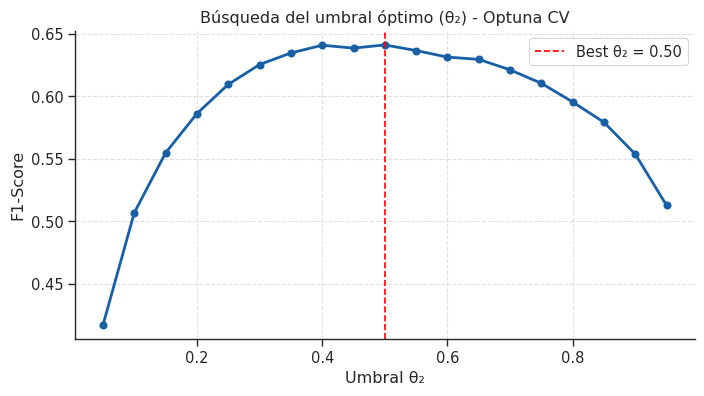

In [ ]:
best_th2_opt, best_f1_th2_opt, df_th2_opt = optimize_theta2(y_test, y_proba_test_optuna, model_name="Optuna CV")

══════════════════════════════════════════════════════════════
 Evaluación Final (Optuna CV) con θ₂ óptimo = 0.50
══════════════════════════════════════════════════════════════

              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00   1013870
      Lavado       0.82      0.52      0.64      1798

    accuracy                           1.00   1015668
   macro avg       0.91      0.76      0.82   1015668
weighted avg       1.00      1.00      1.00   1015668



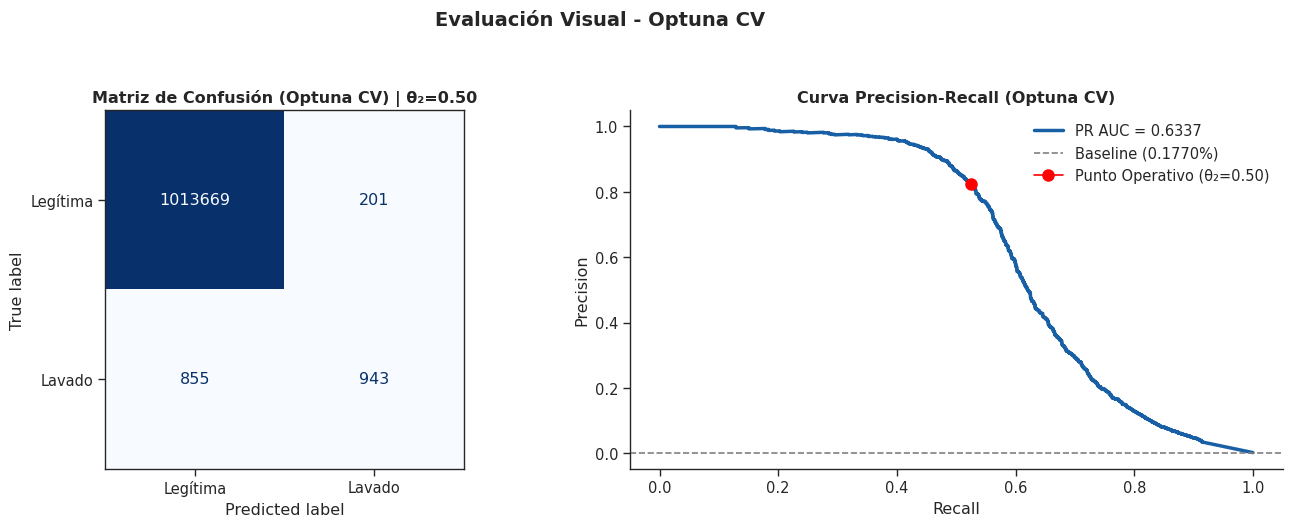

In [ ]:
from sklearn.metrics import classification_report

print(f"{'═'*62}")
print(f" Evaluación Final (Optuna CV) con θ₂ óptimo = {best_th2_opt:.2f}")
print(f"{'═'*62}\n")

# Predicciones finales con el umbral óptimo θ₂
y_pred_test_optuna_final = (y_proba_test_optuna >= best_th2_opt).astype(int)

# Reporte de clasificación
print(classification_report(y_test, y_pred_test_optuna_final, target_names=['Legítima', 'Lavado']))

# Visualización usando la función reutilizable
plot_evaluation_metrics(y_test, y_pred_test_optuna_final, y_proba_test_optuna, model_name="Optuna CV", th2_opt=best_th2_opt)